<a href="https://colab.research.google.com/github/NOUZHAK/code-taux-de-d-faut/blob/main/RPAtests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ##############################################################################
# BLOC 1 — IMPORTS + CONFIGURATION (CORRIGÉ — rééquilibrage minimal)
# ##############################################################################

import os
import sys
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    brier_score_loss, fbeta_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ------------------------------------------------------------------------------
# CHEMINS
# ------------------------------------------------------------------------------
FICHIER_SNAPSHOT = os.environ.get(
    "CPR_SNAPSHOT_PATH",
    r"C:\Users\Nezha\Desktop\DATA_BASE\Données historiques\baseclient.xlsx")
FICHIER_PANEL = os.environ.get(
    "CPR_PANEL_PATH",
    r"C:\Users\Nezha\Desktop\DATA_BASE\Données historiques\Historique.parquet")
DOSSIER_SORTIE = os.environ.get("CPR_OUTPUT_DIR", ".")
os.makedirs(DOSSIER_SORTIE, exist_ok=True)

def chemin_sortie(nom):
    return os.path.join(DOSSIER_SORTIE, nom)

# ------------------------------------------------------------------------------
# PARAMÈTRES TEMPORELS
# ------------------------------------------------------------------------------
SNAPSHOT_DATE    = pd.Timestamp("2020-02-01")
DATE_FIN_HORIZON = pd.Timestamp("2021-01-01")
FENETRE_SEQ      = 24

TARGET_CPR  = "Y_CPR"
SEUIL_NAN   = 40
SEUIL_CORR  = 0.85
SEUIL_IMP   = 0.005
SIZE_TEST   = 0.20
SIZE_VAL    = 0.20
BETA_FSCORE = 3

# ★ CORRECTION : β plus faible = privilégie la précision
BETA_PAR_SCENARIO = {"Conservateur": 0.5, "Optimise": 1.0, "Stresse": 2.0}

# ★ CORRECTION : planchers de précision plus élevés
PRECISION_MIN_PAR_SCENARIO = {"Conservateur": 0.15, "Optimise": 0.08, "Stresse": 0.03}

CALIBRER_PROBABILITES = True
CPR_VINTAGE = 0.0244

# ★★★ CORRECTION MAJEURE : SMOTE à 0 partout, class_weights DRASTIQUEMENT réduits
SCENARIOS = {
    "Conservateur": {
        "reglog":  {"C": 0.01, "smote_ratio": 0.0},      # ← 0.10 → 0.0
        "rf":      {"max_depth": 5,  "min_samples_leaf": 20, "smote_ratio": 0.0,
                     "class_weight": {0: 1, 1: 3}},      # ← 50 → 3
        "xgb":     {"max_depth": 3,  "learning_rate": 0.02,  "smote_ratio": 0.0,
                    "scale_pos_mult": 1.0},              # ← 3.0 → 1.0 (pas de multiplicateur)
        "lstm":    {"class_weight_mult": 1,  "dropout": 0.40, "smote_ratio": 0.0},
    },
    "Optimise": {
        "reglog":  {"C": 0.10, "smote_ratio": 0.0},
        "rf":      {"max_depth": 8,  "min_samples_leaf": 10, "smote_ratio": 0.0,
                     "class_weight": {0: 1, 1: 5}},      # ← 80 → 5
        "xgb":     {"max_depth": 4,  "learning_rate": 0.03,  "smote_ratio": 0.0,
                    "scale_pos_mult": 1.0},              # ← 5.0 → 1.0
        "lstm":    {"class_weight_mult": 2,  "dropout": 0.30, "smote_ratio": 0.0},
    },
    "Stresse": {
        "reglog":  {"C": 1.00, "smote_ratio": 0.0},
        "rf":      {"max_depth": 12, "min_samples_leaf": 5,  "smote_ratio": 0.0,
                     "class_weight": {0: 1, 1: 8}},      # ← 120 → 8
        "xgb":     {"max_depth": 6,  "learning_rate": 0.05,  "smote_ratio": 0.0,
                    "scale_pos_mult": 1.5},              # ← 8.0 → 1.5
        "lstm":    {"class_weight_mult": 3,  "dropout": 0.20, "smote_ratio": 0.0},
    },
}
SCENARIO_REF = "Optimise"
K_SMOTE = 2

LSTM_EPOCHS     = int(os.environ.get("CPR_LSTM_EPOCHS", 100))
LSTM_BATCH      = 64
LSTM_PATIENCE   = 15
LSTM_LR         = 1e-3

RECALL_MIN_CIBLE = 0.50  # ← 0.70 → 0.50 (moins contraignant)

print("=" * 78)
print("  CPR_RPA_LSTM_FINAL.py — chargé (CORRIGÉ — rééquilibrage minimal)")
print(f"  Scénarios : {list(SCENARIOS.keys())}")
print(f"  Fenêtre séquentielle LSTM : {FENETRE_SEQ} mois")
print("=" * 78)

  CPR_RPA_LSTM_FINAL.py — chargé (CORRIGÉ — rééquilibrage minimal)
  Scénarios : ['Conservateur', 'Optimise', 'Stresse']
  Fenêtre séquentielle LSTM : 24 mois


In [ ]:
# ##############################################################################
# BLOC 2 — FONCTIONS UTILITAIRES (CORRIGÉ)
# ##############################################################################

def separateur(titre, niveau=1):
    if niveau == 1:
        print("\n" + "=" * 78)
        print(f"  {titre}")
        print("=" * 78)
    else:
        print(f"\n  --- {titre} ---")

def nettoyer_colonnes(df):
    df.columns = [c.lstrip('\ufeff').strip().lower() for c in df.columns]
    return df

def detecter_cle(df, candidats):
    for c in candidats:
        if c in df.columns:
            return c
    raise KeyError(f"Clé introuvable parmi : {candidats}")

def bootstrap_auc(y_true, y_proba, n_iter=1000, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    aucs = []
    n = len(y_true)
    for _ in range(n_iter):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_proba[idx]))
    if len(aucs) == 0:
        return np.nan, np.nan
    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def opt_seuil(y_val, p_val, y_test, p_test, beta=BETA_FSCORE,
              precision_min=0.0, recall_min=RECALL_MIN_CIBLE):
    """
    Sélection de seuil simple et robuste.
    Ordre : recall+prec → recall seul → prec seul → fallback
    """
    seuils = np.linspace(0.001, 0.999, 1000)
    candidats = []
    for s in seuils:
        y_pred_v = (p_val >= s).astype(int)
        tp_v = int(((y_pred_v == 1) & (y_val == 1)).sum())
        fp_v = int(((y_pred_v == 1) & (y_val == 0)).sum())
        fn_v = int(((y_pred_v == 0) & (y_val == 1)).sum())
        rec_v = tp_v / (tp_v + fn_v) if (tp_v + fn_v) > 0 else 0.0
        prec_v = tp_v / (tp_v + fp_v) if (tp_v + fp_v) > 0 else 0.0
        f_v = fbeta_score(y_val, y_pred_v, beta=beta, zero_division=0)
        candidats.append((f_v, rec_v, prec_v, s))

    tier1 = [(f, s) for f, rec, prec, s in candidats if rec >= recall_min and prec >= precision_min]
    tier2 = [(f, s) for f, rec, prec, s in candidats if rec >= recall_min]
    tier3 = [(f, s) for f, rec, prec, s in candidats if prec >= precision_min]
    tier4 = [(f, s) for f, rec, prec, s in candidats]

    if tier1:
        _, s_opt = max(tier1, key=lambda t: t[0])
        tier_choisi = f"Tier1 (recall≥{recall_min:.0%} & prec≥{precision_min:.0%})"
    elif tier2:
        _, s_opt = max(tier2, key=lambda t: t[0])
        tier_choisi = f"Tier2 (recall≥{recall_min:.0%}, prec libre)"
    elif tier3:
        _, s_opt = max(tier3, key=lambda t: t[0])
        tier_choisi = f"Tier3 (prec≥{precision_min:.0%}, recall libre)"
    else:
        _, s_opt = max(tier4, key=lambda t: t[0])
        tier_choisi = "Tier4 (fallback)"
        rec_max = max(rec for _, rec, _, _ in candidats)
        print(f"    ⚠ ALERTE : rappel max atteignable = {rec_max:.1%} < {recall_min:.0%}")

    y_pred = (p_test >= s_opt).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    rappel    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    specif    = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f_sc      = fbeta_score(y_test, y_pred, beta=beta, zero_division=0)

    print(f"    → Seuil={s_opt:.4f} | {tier_choisi}")
    print(f"    → Test : Rappel={rappel:.1%} | Précision={precision:.1%} | Fβ={f_sc:.4f}")

    return {"Seuil": round(float(s_opt), 5), "VP": int(tp), "FP": int(fp),
            "FN": int(fn), "VN": int(tn), "Rappel": round(rappel, 4),
            "Precision": round(precision, 4), "Specificite": round(specif, 4),
            "Fbeta": round(f_sc, 4), "beta_utilise": beta,
            "tier_seuil": tier_choisi}, cm

def metriques_completes(y_true, y_proba, label=""):
    auc    = roc_auc_score(y_true, y_proba)
    auc_pr = average_precision_score(y_true, y_proba)
    brier  = brier_score_loss(y_true, y_proba)
    lo, hi = bootstrap_auc(y_true, y_proba)
    cap20  = (y_true[y_proba >= np.quantile(y_proba, 0.80)].sum() / y_true.sum()
              if y_true.sum() > 0 else 0.0)
    return {"label": label, "auc": auc, "auc_lo": lo, "auc_hi": hi,
            "auc_pr": auc_pr, "brier": brier, "cpr_pred": float(y_proba.mean()),
            "cpr_reelle": float(y_true.mean()), "cap20": cap20}

def afficher_matrice_confusion(ax, cm, titre, cmap="Blues"):
    cm_pct = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None) * 100
    labels = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)]
                        for i in range(2)])
    sns.heatmap(cm, annot=labels, fmt="", cmap=cmap, linewidths=1, linecolor="white",
                xticklabels=["Prédit Sain", "Prédit RPA"],
                yticklabels=["Réel Sain", "Réel RPA"],
                ax=ax, annot_kws={"size": 10}, cbar=False)
    ax.set_title(titre, fontweight="bold", fontsize=10)
    ax.set_ylabel("Valeur réelle"); ax.set_xlabel("Valeur prédite")

def calculer_psi(expected, actual, n_bins=10):
    bins = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    bins[0] -= 1e-6; bins[-1] += 1e-6
    exp_c = np.histogram(expected, bins=bins)[0]
    act_c = np.histogram(actual,   bins=bins)[0]
    ep = np.where(exp_c == 0, 1e-6, exp_c / len(expected))
    ap = np.where(act_c == 0, 1e-6, act_c / len(actual))
    return float(np.sum((ap - ep) * np.log(ap / ep)))

def calibrer_isotonic(y_val, p_val, p_test):
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_val, y_val)
    return iso.transform(p_val), iso.transform(p_test), iso

print("  BLOC 2 chargé — fonctions utilitaires prêtes")

  BLOC 2 chargé — fonctions utilitaires prêtes


In [ ]:
# ##############################################################################
# BLOC 3 — CHARGEMENT DES 2 BASES (CORRIGÉ — Google Colab)
# ##############################################################################

separateur("3. CHARGEMENT DES 2 BASES")

# ══════════════════════════════════════════════════════════════════════════════
# ★ MONTAGE GOOGLE DRIVE (obligatoire sur Colab)
# ══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

# ══════════════════════════════════════════════════════════════════════════════
# ★ CHEMINS DES FICHIERS
# ══════════════════════════════════════════════════════════════════════════════
FICHIER_SNAPSHOT = "/content/drive/MyDrive/data_PFE/baseclient.xlsx"
FICHIER_PANEL    = "/content/drive/MyDrive/data_PFE/Historique.parquet"

# ══════════════════════════════════════════════════════════════════════════════
# ★ VÉRIFICATION + MESSAGE D'ERREUR EXPLICITE
# ══════════════════════════════════════════════════════════════════════════════

print(f"  Chemin snapshot : {FICHIER_SNAPSHOT}")
print(f"  Chemin panel    : {FICHIER_PANEL}")

if not os.path.exists(FICHIER_SNAPSHOT):
    print(f"\n  ⚠ ERREUR : Fichier introuvable : {FICHIER_SNAPSHOT}")
    print("""
  ╔══════════════════════════════════════════════════════════════════════╗
  ║  Le Drive est monté mais le fichier n'existe pas à ce chemin.       ║
  ║                                                                     ║
  ║  Vérifie :                                                          ║
  ║  1. Que le dossier 'data_PFE' existe bien dans ton Drive            ║
  ║  2. Que 'baseclient.xlsx' est bien dans ce dossier                  ║
  ║  3. Le chemin exact (sensible à la casse) :                         ║
  ║     Mon Drive > data_PFE > baseclient.xlsx                          ║
  ╚══════════════════════════════════════════════════════════════════════╝
  """)
    raise FileNotFoundError(f"Snapshot non trouvé : {FICHIER_SNAPSHOT}")

if not os.path.exists(FICHIER_PANEL):
    print(f"\n  ⚠ ERREUR : Fichier introuvable : {FICHIER_PANEL}")
    raise FileNotFoundError(f"Panel non trouvé : {FICHIER_PANEL}")

print("  ✔ Les deux fichiers sont trouvés, chargement en cours...")

# ══════════════════════════════════════════════════════════════════════════════
# CHARGEMENT EFFECTIF
# ══════════════════════════════════════════════════════════════════════════════

df_snap = pd.read_excel(FICHIER_SNAPSHOT, engine="openpyxl")
df_snap = nettoyer_colonnes(df_snap)
CLE = detecter_cle(df_snap, ["ie_affaire", "bie_affaire", "id_affaire"])
if CLE != "ie_affaire":
    df_snap = df_snap.rename(columns={CLE: "ie_affaire"})
print(f"  df_snap  : {df_snap.shape[0]:,} x {df_snap.shape[1]}")

df_panel = pd.read_parquet(FICHIER_PANEL)
df_panel = nettoyer_colonnes(df_panel)
if "date_obs" not in df_panel.columns:
    if "periode" in df_panel.columns:
        df_panel["date_obs"] = pd.to_datetime(
            df_panel["periode"].astype(str) + "01", format="%Y%m%d")
        df_panel = df_panel.drop(columns=["periode"])
    else:
        raise KeyError("Ni 'date_obs' ni 'periode' trouvés dans le panel")
print(f"  df_panel : {df_panel.shape[0]:,} x {df_panel.shape[1]}")

for col in ["date_creation", "date_debut", "date_fin", "date_naissance"]:
    if col in df_snap.columns and not str(df_snap[col].dtype).startswith("datetime"):
        df_snap[col] = pd.to_datetime(df_snap[col], dayfirst=True, errors="coerce")

for col in ["mensualite","montant_credit","crd","taux_ht","taux_ass","impaye_nombre"]:
    if col in df_snap.columns and df_snap[col].dtype == object:
        df_snap[col] = (df_snap[col].astype(str).str.replace(r"\s+", "", regex=True)
                         .str.replace(",", ".", regex=False)
                         .pipe(pd.to_numeric, errors="coerce"))

print("  BLOC 3 terminé")


  3. CHARGEMENT DES 2 BASES
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Chemin snapshot : /content/drive/MyDrive/data_PFE/baseclient.xlsx
  Chemin panel    : /content/drive/MyDrive/data_PFE/Historique.parquet
  ✔ Les deux fichiers sont trouvés, chargement en cours...
  df_snap  : 36,572 x 31
  df_panel : 2,057,437 x 11
  BLOC 3 terminé


In [ ]:
# ##############################################################################
# BLOC 4 — ISOLEMENT TEMPOREL + CONSTRUCTION DE LA CIBLE Y_CPR
# ##############################################################################

separateur("4. ISOLEMENT TEMPOREL + Y_CPR")

ids_snapshot  = set(df_snap["ie_affaire"].unique())
df_panel_snap = df_panel[df_panel["ie_affaire"].isin(ids_snapshot)].copy()
df_avant = df_panel_snap[df_panel_snap["date_obs"] < SNAPSHOT_DATE].copy()
df_apres = df_panel_snap[
    (df_panel_snap["date_obs"] >= SNAPSHOT_DATE) &
    (df_panel_snap["date_obs"] <= DATE_FIN_HORIZON)].copy()
print(f"  AVANT (historique)  : {len(df_avant):,} observations")
print(f"  APRÈS (horizon 12m) : {len(df_apres):,} observations")

def detecter_rpa(g):
    return int((g["montant_rpa"] > 0).any()) if "montant_rpa" in g.columns else 0

y_cpr = (df_apres.groupby("ie_affaire").apply(detecter_rpa)
         .reset_index().rename(columns={0: TARGET_CPR}))
ids_sans = ids_snapshot - set(y_cpr["ie_affaire"])
if ids_sans:
    y_cpr = pd.concat([y_cpr, pd.DataFrame(
        {"ie_affaire": list(ids_sans), TARGET_CPR: 0})], ignore_index=True)

CPR_OBSERVEE = y_cpr[TARGET_CPR].mean()
SMM_OBSERVE  = 1 - (1 - CPR_OBSERVEE) ** (1 / 12)
print(f"  Y=0 : {(y_cpr[TARGET_CPR]==0).sum():,}   Y=1 (RPA) : {(y_cpr[TARGET_CPR]==1).sum():,}")
print(f"  CPR réelle = {CPR_OBSERVEE:.4%}   SMM = {SMM_OBSERVE:.6f}")

print("  BLOC 4 terminé")




  4. ISOLEMENT TEMPOREL + Y_CPR
  AVANT (historique)  : 1,627,013 observations
  APRÈS (horizon 12m) : 417,015 observations
  Y=0 : 35,970   Y=1 (RPA) : 602
  CPR réelle = 1.6461%   SMM = 0.001382
  BLOC 4 terminé


In [ ]:
# ##############################################################################
# BLOC 5 — AGRÉGATION PANELLE → FEATURES STATIQUES (RegLog / RF / XGBoost)
# ##############################################################################

separateur("5. AGRÉGATION PANELLE — FEATURES STATIQUES")

def agreger_panelle_cpr(group):
    nb_obs = len(group)
    nb_imp_cumul = group["impaye_nombre"].max() if "impaye_nombre" in group.columns else 0
    mt_imp_cumul = group["impaye_montant"].max() if "impaye_montant" in group.columns else 0
    a_eu_impaye  = int(nb_imp_cumul >= 1)
    mois_depuis_1er_imp = 0
    if "impaye_nombre" in group.columns:
        obs_imp = group[group["impaye_nombre"] >= 1]
        if len(obs_imp) > 0:
            mois_depuis_1er_imp = (SNAPSHOT_DATE - obs_imp["date_obs"].min()).days / 30.44
    a_fait_rpa_avant = 0; montant_rpa_avant = 0
    if "montant_rpa" in group.columns:
        montant_rpa_avant = group["montant_rpa"].sum()
        a_fait_rpa_avant  = int(montant_rpa_avant > 0)
    nb_mois_sains = 0
    if "statut_comptable" in group.columns and "impaye_nombre" in group.columns:
        nb_mois_sains = ((group["statut_comptable"].str.upper() == "SNA") &
                          (group["impaye_nombre"] == 0)).sum()
    ratio_mois_sains = nb_mois_sains / nb_obs if nb_obs > 0 else 1.0
    # Vitesse d'amortissement récente (12 derniers mois) — utile en complément
    # de la trajectoire complète que seul le LSTM verra dans BLOC 5bis.
    vitesse_amort_12m = 0.0
    if "crd" in group.columns and nb_obs >= 2:
        g_sorted = group.sort_values("date_obs")
        recent = g_sorted.tail(12)
        if len(recent) >= 2 and recent["crd"].iloc[0] > 0:
            vitesse_amort_12m = ((recent["crd"].iloc[0] - recent["crd"].iloc[-1])
                                  / recent["crd"].iloc[0])
    return pd.Series({
        "nb_obs_avant": nb_obs, "nb_imp_cumul": nb_imp_cumul,
        "mt_imp_cumul": mt_imp_cumul, "a_eu_impaye": a_eu_impaye,
        "mois_depuis_1er_imp": mois_depuis_1er_imp,
        "a_fait_rpa_avant": a_fait_rpa_avant,
        "montant_rpa_avant": montant_rpa_avant,
        "ratio_mois_sains": ratio_mois_sains,
        "vitesse_amort_12m": vitesse_amort_12m,
    })

df_feat_pan = df_avant.groupby("ie_affaire").apply(agreger_panelle_cpr).reset_index()
print(f"  {len(df_feat_pan):,} créances | {df_feat_pan.shape[1]-1} features agrégées")
print("  BLOC 5 terminé")


# ##############################################################################
# BLOC 5BIS — CONSTRUCTION DES SÉQUENCES MENSUELLES (POUR LE LSTM)
# ##############################################################################
# Chaque créance devient un tenseur (FENETRE_SEQ, n_features_seq) =
# les FENETRE_SEQ derniers mois observés avant la date de snapshot.
# Padding à gauche (les créances plus jeunes ont des zéros en début de
# séquence) + masque pour que le LSTM ignore le padding.
# C'est cette information de TRAJECTOIRE (et non de simple agrégat) qui
# constitue l'avantage informationnel du LSTM.
# ##############################################################################

separateur("5BIS. CONSTRUCTION DES SÉQUENCES MENSUELLES — LSTM")

FEATURES_SEQ = ["impaye_nombre_n", "impaye_montant_n", "indic_sain",
                 "crd_ratio", "delta_crd_n"]

def construire_sequences(df_avant, ids_ordre, fenetre=FENETRE_SEQ):
    """
    Retourne X_seq de forme (n_ids, fenetre, n_features_seq) et le masque
    implicite (zéros = padding, repérés via Masking(mask_value=0.) côté Keras
    seulement si AUCUNE feature réelle ne vaut exactement 0 pour un mois
    observé — on utilise donc une feature dédiée 'mois_observe' à la place,
    plus robuste).
    """
    n = len(ids_ordre)
    n_feat = len(FEATURES_SEQ) + 1  # +1 pour le flag 'mois_observe'
    X_seq = np.zeros((n, fenetre, n_feat), dtype=np.float32)

    g = df_avant.sort_values("date_obs").groupby("ie_affaire")
    idx_map = {idd: i for i, idd in enumerate(ids_ordre)}

    for idd, grp in g:
        if idd not in idx_map:
            continue
        i = idx_map[idd]
        grp = grp.tail(fenetre).copy()
        if len(grp) == 0:
            continue
        crd0 = grp["crd"].iloc[0] if "crd" in grp.columns and grp["crd"].iloc[0] > 0 else np.nan
        impaye_nombre = grp["impaye_nombre"].fillna(0).values if "impaye_nombre" in grp.columns else np.zeros(len(grp))
        impaye_montant = grp["impaye_montant"].fillna(0).values if "impaye_montant" in grp.columns else np.zeros(len(grp))
        crd_vals = grp["crd"].ffill().fillna(0).values if "crd" in grp.columns else np.zeros(len(grp))
        statut = grp["statut_comptable"].astype(str).str.upper().values if "statut_comptable" in grp.columns else np.array(["SNA"] * len(grp))

        indic_sain  = ((statut == "SNA") & (impaye_nombre == 0)).astype(float)
        crd_ratio   = (crd_vals / crd0) if (crd0 and not np.isnan(crd0) and crd0 > 0) else np.zeros(len(grp))
        delta_crd   = np.diff(crd_vals, prepend=crd_vals[0] if len(crd_vals) else 0)
        delta_crd_n = (delta_crd / crd0) if (crd0 and not np.isnan(crd0) and crd0 > 0) else np.zeros(len(grp))

        L = len(grp)
        # padding à gauche : les L dernières positions de la fenêtre sont remplies
        X_seq[i, fenetre - L:, 0] = np.clip(impaye_nombre / 12.0, 0, 3)   # normalisation grossière
        X_seq[i, fenetre - L:, 1] = np.clip(impaye_montant / (crd0 if crd0 and not np.isnan(crd0) and crd0 > 0 else 1), 0, 3)
        X_seq[i, fenetre - L:, 2] = indic_sain
        X_seq[i, fenetre - L:, 3] = np.clip(crd_ratio, 0, 2)
        X_seq[i, fenetre - L:, 4] = np.clip(delta_crd_n, -1, 1)
        X_seq[i, fenetre - L:, 5] = 1.0   # mois_observe = 1 (vs 0 = padding)

    return X_seq

print(f"  Fenêtre séquentielle : {FENETRE_SEQ} mois | features par mois : {len(FEATURES_SEQ)} (+ flag observé)")
print("  La construction effective des tenseurs (X_seq_train/val/test) se fait")
print("  au BLOC 9, une fois le split train/val/test connu (mêmes ie_affaire).")
print("  BLOC 5BIS terminé")



  5. AGRÉGATION PANELLE — FEATURES STATIQUES
  36,572 créances | 9 features agrégées
  BLOC 5 terminé

  5BIS. CONSTRUCTION DES SÉQUENCES MENSUELLES — LSTM
  Fenêtre séquentielle : 24 mois | features par mois : 5 (+ flag observé)
  La construction effective des tenseurs (X_seq_train/val/test) se fait
  au BLOC 9, une fois le split train/val/test connu (mêmes ie_affaire).
  BLOC 5BIS terminé


In [ ]:
# ##############################################################################
# BLOC 6 — AGRÉGATION PANELLE → FEATURES STATIQUES
# ##############################################################################

separateur("6. AGRÉGATION PANELLE — FEATURES STATIQUES")

def agreger_panelle_cpr(group):
    nb_obs = len(group)
    nb_imp_cumul = group["impaye_nombre"].max() if "impaye_nombre" in group.columns else 0
    mt_imp_cumul = group["impaye_montant"].max() if "impaye_montant" in group.columns else 0
    a_eu_impaye  = int(nb_imp_cumul >= 1)
    mois_depuis_1er_imp = 0
    if "impaye_nombre" in group.columns:
        obs_imp = group[group["impaye_nombre"] >= 1]
        if len(obs_imp) > 0:
            mois_depuis_1er_imp = (SNAPSHOT_DATE - obs_imp["date_obs"].min()).days / 30.44
    a_fait_rpa_avant = 0; montant_rpa_avant = 0
    if "montant_rpa" in group.columns:
        montant_rpa_avant = group["montant_rpa"].sum()
        a_fait_rpa_avant  = int(montant_rpa_avant > 0)
    nb_mois_sains = 0
    if "statut_comptable" in group.columns and "impaye_nombre" in group.columns:
        nb_mois_sains = ((group["statut_comptable"].str.upper() == "SNA") &
                          (group["impaye_nombre"] == 0)).sum()
    ratio_mois_sains = nb_mois_sains / nb_obs if nb_obs > 0 else 1.0
    vitesse_amort_12m = 0.0
    if "crd" in group.columns and nb_obs >= 2:
        g_sorted = group.sort_values("date_obs")
        recent = g_sorted.tail(12)
        if len(recent) >= 2 and recent["crd"].iloc[0] > 0:
            vitesse_amort_12m = ((recent["crd"].iloc[0] - recent["crd"].iloc[-1])
                                  / recent["crd"].iloc[0])
    return pd.Series({
        "nb_obs_avant": nb_obs, "nb_imp_cumul": nb_imp_cumul,
        "mt_imp_cumul": mt_imp_cumul, "a_eu_impaye": a_eu_impaye,
        "mois_depuis_1er_imp": mois_depuis_1er_imp,
        "a_fait_rpa_avant": a_fait_rpa_avant,
        "montant_rpa_avant": montant_rpa_avant,
        "ratio_mois_sains": ratio_mois_sains,
        "vitesse_amort_12m": vitesse_amort_12m,
    })

# ★ GARDE-FOU : vérifier que df_avant existe (créé au BLOC 4)
try:
    df_avant
except NameError:
    raise RuntimeError(
        "df_avant n'existe pas. Ré-exécute le BLOC 4 "
        "(isolement temporel + construction Y_CPR) avant le BLOC 5."
    )

df_feat_pan = df_avant.groupby("ie_affaire").apply(agreger_panelle_cpr).reset_index()
print(f"  {len(df_feat_pan):,} créances | {df_feat_pan.shape[1]-1} features agrégées")
print("  BLOC 5 terminé")


# ##############################################################################
# BLOC 6 — FUSION + FEATURE ENGINEERING (FEATURES STATIQUES)
# ##############################################################################

separateur("6. FUSION + FEATURE ENGINEERING")

# ★ GARDE-FOU : vérifier que df_feat_pan existe
try:
    df_feat_pan
except NameError:
    raise RuntimeError(
        "df_feat_pan n'existe pas. Ré-exécute le BLOC 5 "
        "(agrégation panelle) avant le BLOC 6."
    )

df = df_snap.merge(df_feat_pan, on="ie_affaire", how="left")
df = df.merge(y_cpr, on="ie_affaire", how="inner")
print(f"  Fusion : {df.shape[0]:,} x {df.shape[1]}")

for col, val in {
    "nb_obs_avant": 0, "nb_imp_cumul": 0, "mt_imp_cumul": 0, "a_eu_impaye": 0,
    "mois_depuis_1er_imp": 0, "a_fait_rpa_avant": 0, "montant_rpa_avant": 0,
    "ratio_mois_sains": 1.0, "vitesse_amort_12m": 0.0,
}.items():
    if col in df.columns:
        df[col] = df[col].fillna(val)

if "date_naissance" in df.columns and not str(df["date_naissance"].dtype).startswith("datetime"):
    df["date_naissance"] = pd.to_datetime(df["date_naissance"], errors="coerce")
if "date_creation" in df.columns:
    df["anciennete_mois"] = ((SNAPSHOT_DATE - df["date_creation"]).dt.days / 30.44).round(1)
col_fin = next((c for c in ["date_fin", "date_fin_echeance"] if c in df.columns), None)
if col_fin:
    df["duree_residuelle"] = ((df[col_fin] - SNAPSHOT_DATE).dt.days / 30.44).clip(lower=0).round(1)
if "date_naissance" in df.columns:
    df["age_emprunteur"] = ((SNAPSHOT_DATE - df["date_naissance"]).dt.days / 365.25).round(1)
    df["age_emprunteur"] = df["age_emprunteur"].where(
        (df["age_emprunteur"] >= 18) & (df["age_emprunteur"] <= 80), np.nan)
if "crd" in df.columns and "montant_credit" in df.columns:
    df["ratio_crd"] = (df["crd"] / df["montant_credit"].replace(0, np.nan)).clip(upper=1.0)
col_revenu = next((c for c in ["revenu_annuel", "revenu annuel wi"] if c in df.columns), None)
if "mensualite" in df.columns and col_revenu:
    df["taux_effort"] = (df["mensualite"] * 12) / df[col_revenu].replace(0, np.nan)
if "taux_ht" in df.columns and "taux_ass" in df.columns:
    df["taux_total"] = df["taux_ht"] + df["taux_ass"]

COLS_SOURCES = [
    "date_creation", "date_debut", "date_fin", "date_fin_echeance", "date_naissance",
    "crd", "montant_credit", "taux_ht", "taux_ass", "differe", "différé",
    "montant_bien", "montant_garantie", "revenu_annuel", "revenu annuel wi",
    "date_debut_echeance",
]
df = df.drop(columns=[c for c in COLS_SOURCES if c in df.columns], errors="ignore")
for c in list(df.select_dtypes(include="number").columns):
    if c not in [TARGET_CPR, "ie_affaire"] and df[c].nunique() <= 1:
        df = df.drop(columns=[c])
COLS_SUPPR = [
    "montant_rpa", "mode_reglement", "statut_comptable", "impaye_nombre", "impaye_montant",
    "type_taux", "taux_tva", "employeur", "annee_production", "loan_to_value", "tiers_client",
    "pays_residence", "ville_bien", "ville_residence", "code_convention",
    "montant_debloque", "code_statut_compta",
]
df = df.drop(columns=[c for c in COLS_SUPPR if c in df.columns], errors="ignore")
print(f"  Dimensions après feature engineering : {df.shape[0]:,} x {df.shape[1]}")
print("  BLOC 6 terminé")


  6. AGRÉGATION PANELLE — FEATURES STATIQUES
  36,572 créances | 9 features agrégées
  BLOC 5 terminé

  6. FUSION + FEATURE ENGINEERING
  Fusion : 36,572 x 41
  Dimensions après feature engineering : 36,572 x 24
  BLOC 6 terminé


In [ ]:
# BLOC 7 — SÉLECTION DE VARIABLES (tests statistiques + importance RF)
# ##############################################################################

separateur("7. SÉLECTION DE VARIABLES")

REGROUPEMENT_PROFESSION = {
    'INSTITUTEUR':'ENSEIGNEMENT','PROFESSEUR 1ER CYCLE':'ENSEIGNEMENT',
    'PROFESSEUR SEC. CYCLE':'ENSEIGNEMENT','PROFESSEUR 3IEME CYCLE':'ENSEIGNEMENT',
    'MILITAIRE : SOUS-OFFICIER':'SECURITE_DEFENSE','MILITAIRES':'SECURITE_DEFENSE',
    'POLICIERS ET MILITAIRES':'SECURITE_DEFENSE',
    'ADMINISTRATEUR F. PUBLIQUE':'ADMINISTRATION','AGENT F. PUBLIQUE':'ADMINISTRATION',
    'CADRES':'ADMINISTRATION',
}
col_prof = next((c for c in ["profession"] if c in df.columns), None)
if col_prof:
    df["secteur_profession"] = df[col_prof].map(REGROUPEMENT_PROFESSION).fillna("AUTRE")
    df = df.drop(columns=[col_prof], errors="ignore")

for col in [c for c in ["objet_financement","domicilie","situation_famille","qualite"] if c in df.columns]:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.02].index.tolist(), "AUTRE")

FEATURES_NUM = [c for c in [
    "anciennete_mois","duree_residuelle","ratio_crd","taux_effort",
    "age_emprunteur","taux_total","mensualite","duree",
    "nb_obs_avant","nb_imp_cumul","mt_imp_cumul","a_eu_impaye",
    "mois_depuis_1er_imp","ratio_mois_sains","a_fait_rpa_avant","montant_rpa_avant",
    "vitesse_amort_12m",
] if c in df.columns]

FEATURES_CAT = [c for c in [
    "objet_financement","domicilie","qualite","secteur_profession","situation_famille",
] if c in df.columns]

cols_trop_nan = [c for c in FEATURES_NUM + FEATURES_CAT if df[c].isna().mean()*100 > SEUIL_NAN]
FEATURES_NUM = [c for c in FEATURES_NUM if c not in cols_trop_nan and df[c].nunique() > 1]
FEATURES_CAT = [c for c in FEATURES_CAT if c not in cols_trop_nan]
ALL_FEATURES = FEATURES_NUM + FEATURES_CAT

df_tmp = df[FEATURES_NUM].fillna(df[FEATURES_NUM].median())
corr_m = df_tmp.corr(method="pearson")
cols_c = corr_m.columns.tolist()
paires = [(cols_c[i], cols_c[j], round(abs(corr_m.iloc[i,j]),3))
          for i in range(len(cols_c)) for j in range(i+1,len(cols_c))
          if abs(corr_m.iloc[i,j]) >= SEUIL_CORR]
COLS_EXCLURE = []
for v1, v2, r in sorted(paires, key=lambda x: -x[2]):
    to_drop = v2
    if to_drop in FEATURES_NUM and to_drop not in COLS_EXCLURE:
        COLS_EXCLURE.append(to_drop)
        print(f"  r={r} : SUPPRIME {to_drop:<30} (corrélé à {v1})")
FEATURES_NUM = [c for c in FEATURES_NUM if c not in COLS_EXCLURE]
ALL_FEATURES = FEATURES_NUM + FEATURES_CAT

df_ts = df[ALL_FEATURES + [TARGET_CPR]].copy()
for c in FEATURES_NUM:
    df_ts[c] = df_ts[c].fillna(df_ts[c].median())
for c in FEATURES_CAT:
    m = df_ts[c].mode()
    df_ts[c] = df_ts[c].fillna(m[0] if len(m) > 0 else "INC")
y_vec = df_ts[TARGET_CPR]

resultats = []
for col in FEATURES_NUM:
    _, pval = stats.mannwhitneyu(df_ts.loc[y_vec==0,col], df_ts.loc[y_vec==1,col], alternative="two-sided")
    resultats.append({"Variable":col,"Type":"Num.","p-value":round(pval,5)})
for col in FEATURES_CAT:
    ct = pd.crosstab(df_ts[col], y_vec)
    _, pval, _, _ = stats.chi2_contingency(ct)
    resultats.append({"Variable":col,"Type":"Cat.","p-value":round(pval,5)})
df_tests = pd.DataFrame(resultats).sort_values("p-value")

X_rf_sel = df_ts[ALL_FEATURES].copy()
for c in FEATURES_CAT:
    X_rf_sel[c] = X_rf_sel[c].astype("category").cat.codes
rf_sel = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                 class_weight="balanced", n_jobs=-1)
rf_sel.fit(X_rf_sel, y_vec)
imp_df = pd.DataFrame({"Variable":ALL_FEATURES,
                        "Importance":rf_sel.feature_importances_}).sort_values("Importance", ascending=False)

print("\n  Top 15 importance Gini (sélection) :")
print(imp_df.head(15).to_string(index=False))

cols_non_sig = df_tests[df_tests["p-value"] > 0.20]["Variable"].tolist()
cols_faible  = imp_df[imp_df["Importance"] < SEUIL_IMP]["Variable"].tolist()
cols_auto    = set(cols_non_sig) & set(cols_faible)
for c in cols_auto:
    for lst in [FEATURES_NUM, FEATURES_CAT]:
        if c in lst:
            lst.remove(c)
            print(f"  SUPPRIME (auto, p>0.20 ET imp<{SEUIL_IMP}) : {c}")

ALL_FEATURES = FEATURES_NUM + FEATURES_CAT
print(f"\n  Features finales : {len(ALL_FEATURES)}")
print(f"  Num ({len(FEATURES_NUM)}) : {FEATURES_NUM}")
print(f"  Cat ({len(FEATURES_CAT)}) : {FEATURES_CAT}")

df_synthese = (df_tests[df_tests["Variable"].isin(ALL_FEATURES)]
    .merge(imp_df[imp_df["Variable"].isin(ALL_FEATURES)].rename(columns={"Importance":"Imp_RF"}),
           on="Variable", how="left")
    .sort_values("Imp_RF", ascending=False))

print("  BLOC 7 terminé")




  7. SÉLECTION DE VARIABLES
  r=0.858 : SUPPRIME duree                          (corrélé à duree_residuelle)
  r=0.852 : SUPPRIME nb_obs_avant                   (corrélé à anciennete_mois)

  Top 15 importance Gini (sélection) :
          Variable  Importance
   anciennete_mois    0.140278
         ratio_crd    0.123479
        mensualite    0.122827
       taux_effort    0.116201
 vitesse_amort_12m    0.115206
    age_emprunteur    0.100840
  duree_residuelle    0.083700
        taux_total    0.083565
secteur_profession    0.027540
           qualite    0.014507
 montant_rpa_avant    0.013401
 situation_famille    0.013272
 objet_financement    0.012704
         domicilie    0.009040
  a_fait_rpa_avant    0.008828
  SUPPRIME (auto, p>0.20 ET imp<0.005) : a_eu_impaye
  SUPPRIME (auto, p>0.20 ET imp<0.005) : mt_imp_cumul
  SUPPRIME (auto, p>0.20 ET imp<0.005) : nb_imp_cumul
  SUPPRIME (auto, p>0.20 ET imp<0.005) : mois_depuis_1er_imp
  SUPPRIME (auto, p>0.20 ET imp<0.005) : ratio_mois_

In [ ]:
# BLOC 8 — SPLIT TRAIN / VAL / TEST (stratifié, partagé par les 4 modèles)
# ##############################################################################

separateur("8. SPLIT TRAIN(60%) / VAL(20%) / TEST(20%)")

df_model = df[ALL_FEATURES + [TARGET_CPR, "ie_affaire"]].copy()
y_raw   = df_model[TARGET_CPR].values
idx_all = np.arange(len(y_raw))
idx_trainval, idx_test = train_test_split(
    idx_all, test_size=SIZE_TEST, random_state=RANDOM_STATE, stratify=y_raw)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=SIZE_VAL/(1-SIZE_TEST),
    random_state=RANDOM_STATE, stratify=y_raw[idx_trainval])

df_train_raw = df_model.iloc[idx_train].copy()
df_val_raw   = df_model.iloc[idx_val].copy()
df_test_raw  = df_model.iloc[idx_test].copy()
y_train_raw  = y_raw[idx_train]
y_val        = y_raw[idx_val]
y_test       = y_raw[idx_test]

ids_train = df_train_raw["ie_affaire"].values
ids_val   = df_val_raw["ie_affaire"].values
ids_test  = df_test_raw["ie_affaire"].values

print(f"\n  {'Ensemble':<12} {'N':>8}  {'Y=0':>8}  {'Y=1':>6}  {'CPR':>9}")
for label, y_s in [("Train(60%)",y_train_raw),("Val(20%)",y_val),("Test(20%)",y_test)]:
    print(f"  {label:<12} {len(y_s):>8,}  {(y_s==0).sum():>8,}  {(y_s==1).sum():>6}  {y_s.mean():>9.4%}")
print("  BLOC 8 terminé")


# ##############################################################################


  8. SPLIT TRAIN(60%) / VAL(20%) / TEST(20%)

  Ensemble            N       Y=0     Y=1        CPR
  Train(60%)     21,942    21,581     361    1.6452%
  Val(20%)        7,315     7,194     121    1.6541%
  Test(20%)       7,315     7,195     120    1.6405%
  BLOC 8 terminé


In [ ]:
# ##############################################################################
# BLOC 9 — CONSTRUCTION DES SÉQUENCES MENSUELLES (POUR LE LSTM)
# ##############################################################################

separateur("9. CONSTRUCTION DES SÉQUENCES MENSUELLES — LSTM")

# ★ GARDE-FOU : vérifier que df_avant existe
try:
    df_avant
except NameError:
    raise RuntimeError(
        "df_avant n'existe pas. Ré-exécute le BLOC 4 "
        "(isolement temporel) avant le BLOC 5BIS."
    )

FEATURES_SEQ = ["impaye_nombre_n", "impaye_montant_n", "indic_sain",
                 "crd_ratio", "delta_crd_n"]

def construire_sequences(df_avant, ids_ordre, fenetre=FENETRE_SEQ):
    """
    Retourne X_seq de forme (n_ids, fenetre, n_features_seq).
    Padding à gauche, flag 'mois_observe' en dernière colonne.
    """
    n = len(ids_ordre)
    n_feat = len(FEATURES_SEQ) + 1  # +1 pour le flag 'mois_observe'
    X_seq = np.zeros((n, fenetre, n_feat), dtype=np.float32)

    g = df_avant.sort_values("date_obs").groupby("ie_affaire")
    idx_map = {idd: i for i, idd in enumerate(ids_ordre)}

    for idd, grp in g:
        if idd not in idx_map:
            continue
        i = idx_map[idd]
        grp = grp.tail(fenetre).copy()
        if len(grp) == 0:
            continue
        crd0 = grp["crd"].iloc[0] if "crd" in grp.columns and grp["crd"].iloc[0] > 0 else np.nan
        impaye_nombre = grp["impaye_nombre"].fillna(0).values if "impaye_nombre" in grp.columns else np.zeros(len(grp))
        impaye_montant = grp["impaye_montant"].fillna(0).values if "impaye_montant" in grp.columns else np.zeros(len(grp))
        crd_vals = grp["crd"].ffill().fillna(0).values if "crd" in grp.columns else np.zeros(len(grp))
        statut = grp["statut_comptable"].astype(str).str.upper().values if "statut_comptable" in grp.columns else np.array(["SNA"] * len(grp))

        indic_sain  = ((statut == "SNA") & (impaye_nombre == 0)).astype(float)
        crd_ratio   = (crd_vals / crd0) if (crd0 and not np.isnan(crd0) and crd0 > 0) else np.zeros(len(grp))
        delta_crd   = np.diff(crd_vals, prepend=crd_vals[0] if len(crd_vals) else 0)
        delta_crd_n = (delta_crd / crd0) if (crd0 and not np.isnan(crd0) and crd0 > 0) else np.zeros(len(grp))

        L = len(grp)
        # padding à gauche : les L dernières positions de la fenêtre sont remplies
        X_seq[i, fenetre - L:, 0] = np.clip(impaye_nombre / 12.0, 0, 3)
        X_seq[i, fenetre - L:, 1] = np.clip(impaye_montant / (crd0 if crd0 and not np.isnan(crd0) and crd0 > 0 else 1), 0, 3)
        X_seq[i, fenetre - L:, 2] = indic_sain
        X_seq[i, fenetre - L:, 3] = np.clip(crd_ratio, 0, 2)
        X_seq[i, fenetre - L:, 4] = np.clip(delta_crd_n, -1, 1)
        X_seq[i, fenetre - L:, 5] = 1.0   # mois_observe = 1 (vs 0 = padding)

    return X_seq

print(f"  Fenêtre séquentielle : {FENETRE_SEQ} mois | features par mois : {len(FEATURES_SEQ)} (+ flag observé)")
print("  BLOC 5BIS terminé")


# ##############################################################################
# BLOC 9 — PRÉPARATION DES MATRICES (RegLog / RF / XGB / LSTM)
# ##############################################################################

separateur("9. PRÉPARATION DES MATRICES")

# ★ GARDE-FOU : vérifier que les objets des blocs précédents existent
objets_bloc9 = {
    "df_train_raw": "BLOC 8 (split)", "df_val_raw": "BLOC 8 (split)",
    "df_test_raw": "BLOC 8 (split)", "FEATURES_NUM": "BLOC 7 (sélection)",
    "FEATURES_CAT": "BLOC 7 (sélection)",
}
manquants = [(o, b) for o, b in objets_bloc9.items() if o not in globals()]
if manquants:
    for o, b in manquants:
        print(f"  ❌ {o} manquant → {b}")
    raise RuntimeError("Ré-exécute BLOC 7 → 8 avant BLOC 9.")

# ---- 9A. Winsorisation + imputation (médiane/mode appris sur TRAIN) --------
medians_train = {}; modes_train = {}; winsor_bounds = {}
COLS_WINS = [c for c in [
    "anciennete_mois","duree_residuelle","ratio_crd","mensualite","taux_total",
    "nb_obs_avant","mt_imp_cumul","ratio_mois_sains","age_emprunteur",
    "montant_rpa_avant","vitesse_amort_12m",
] if c in FEATURES_NUM]
for col in COLS_WINS:
    p1, p99 = df_train_raw[col].quantile(0.01), df_train_raw[col].quantile(0.99)
    winsor_bounds[col] = (float(p1), float(p99))
    for d in [df_train_raw, df_val_raw, df_test_raw]:
        d[col] = d[col].clip(lower=p1, upper=p99)
for c in FEATURES_NUM:
    med = df_train_raw[c].median(); medians_train[c] = med
    for d in [df_train_raw, df_val_raw, df_test_raw]:
        d[c] = d[c].fillna(med)
for c in FEATURES_CAT:
    mv = df_train_raw[c].mode()[0] if df_train_raw[c].notna().any() else "INC"
    modes_train[c] = mv
    for d in [df_train_raw, df_val_raw, df_test_raw]:
        d[c] = d[c].fillna(mv)

# ---- 9B. RegLog : OHE + StandardScaler --------------------------------------
ohe    = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")
scaler = StandardScaler()
ohe.fit(df_train_raw[FEATURES_CAT]); scaler.fit(df_train_raw[FEATURES_NUM])
ohe_cols = ohe.get_feature_names_out(FEATURES_CAT).tolist()
FEATURE_COLS = FEATURES_NUM + ohe_cols

def build_lr_matrix(d):
    num = pd.DataFrame(scaler.transform(d[FEATURES_NUM]), columns=FEATURES_NUM, index=d.index)
    oh  = pd.DataFrame(ohe.transform(d[FEATURES_CAT]), columns=ohe_cols, index=d.index)
    return pd.concat([num.reset_index(drop=True), oh.reset_index(drop=True)], axis=1).values

X_train_lr_raw = build_lr_matrix(df_train_raw)
X_val_lr       = build_lr_matrix(df_val_raw)
X_test_lr      = build_lr_matrix(df_test_raw)

# ---- 9C. Arbres (RF / XGBoost) : encodage catégoriel simple -----------------
def preparer_tree(d):
    dc = d.copy()
    for c in FEATURES_NUM:
        dc[c] = dc[c].fillna(medians_train[c])
    for c in FEATURES_CAT:
        dc[c] = pd.Categorical(dc[c].fillna(modes_train[c]),
                                categories=CATEGORIES_FIXES[c]).codes
    return dc[FEATURES_NUM + FEATURES_CAT].values

# Catégories figées sur TRAIN
CATEGORIES_FIXES = {c: sorted(df_train_raw[c].dropna().unique().tolist()) for c in FEATURES_CAT}

X_train_tree_raw = preparer_tree(df_train_raw)
X_val_tree       = preparer_tree(df_val_raw)
X_test_tree      = preparer_tree(df_test_raw)
print(f"  RegLog : {len(FEATURE_COLS)} colonnes (après OHE) | Arbres : {len(FEATURES_NUM+FEATURES_CAT)} colonnes")

# ---- 9D. LSTM : séquences mensuelles + normalisation ------------------------
# ★ GARDE-FOU : vérifier que construire_sequences existe
try:
    construire_sequences
except NameError:
    raise RuntimeError(
        "construire_sequences n'existe pas. Ré-exécute le BLOC 5BIS "
        "(construction séquences LSTM) avant le BLOC 9."
    )

X_seq_train_raw = construire_sequences(df_avant, ids_train)
X_seq_val       = construire_sequences(df_avant, ids_val)
X_seq_test      = construire_sequences(df_avant, ids_test)

# Normalisation séquentielle
seq_means = np.zeros(X_seq_train_raw.shape[-1]); seq_stds = np.ones(X_seq_train_raw.shape[-1])
mask_train = X_seq_train_raw[:, :, -1] == 1
for k in [0, 1, 3, 4]:
    vals = X_seq_train_raw[:, :, k][mask_train]
    if len(vals) > 0 and vals.std() > 1e-8:
        seq_means[k] = vals.mean(); seq_stds[k] = vals.std()

def normaliser_seq(X_seq):
    Xc = X_seq.copy()
    for k in [0, 1, 3, 4]:
        Xc[:, :, k] = np.where(Xc[:, :, -1] == 1, (Xc[:, :, k]-seq_means[k])/seq_stds[k], 0.0)
    return Xc

X_seq_train_raw = normaliser_seq(X_seq_train_raw)
X_seq_val       = normaliser_seq(X_seq_val)
X_seq_test      = normaliser_seq(X_seq_test)
print(f"  LSTM   : tenseur séquentiel {X_seq_train_raw.shape}")

# LSTM — branche statique
X_train_static_raw = X_train_lr_raw.copy()
X_val_static        = X_val_lr.copy()
X_test_static        = X_test_lr.copy()

print("  BLOC 9 terminé")


  9. CONSTRUCTION DES SÉQUENCES MENSUELLES — LSTM
  Fenêtre séquentielle : 24 mois | features par mois : 5 (+ flag observé)
  BLOC 5BIS terminé

  9. PRÉPARATION DES MATRICES
  RegLog : 19 colonnes (après OHE) | Arbres : 15 colonnes
  LSTM   : tenseur séquentiel (21942, 24, 6)
  BLOC 9 terminé


In [ ]:
# ##############################################################################
# BLOC 10 — STRUCTURE DE STOCKAGE DES RÉSULTATS + SMOTE PARAMÉTRABLE
# ##############################################################################

separateur("10. SMOTE PARAMÉTRABLE PAR SCÉNARIO")

RESULTATS = {}   # clé = (nom_modele, scenario) -> dict (probas, métriques, seuil...)
MODELES_ENTRAINES = {}  # objets modèles sauvegardés pour SHAP/LIME/export
CALIBRATEURS = {}       # objets IsotonicRegression par (modele, scenario)

def appliquer_smote(X, y, ratio, k=K_SMOTE):
    n_min = (y == 1).sum()
    n_maj = (y == 0).sum()
    ratio_actuel = n_min / max(n_maj, 1)
    if ratio_actuel >= ratio or n_min < 2:
        return X, y
    k_eff = min(k, max(1, n_min - 1))
    sm = SMOTE(sampling_strategy=ratio, random_state=RANDOM_STATE, k_neighbors=k_eff)
    return sm.fit_resample(X, y)

print("  Ratios SMOTE par scénario :")
for sc, cfg in SCENARIOS.items():
    print(f"    {sc:<14} RegLog={cfg['reglog']['smote_ratio']:.0%}  "
          f"RF={cfg['rf']['smote_ratio']:.0%}  XGB={cfg['xgb']['smote_ratio']:.0%}  "
          f"LSTM={cfg['lstm']['smote_ratio']:.0%}")
print("  BLOC 10 terminé")


  10. SMOTE PARAMÉTRABLE PAR SCÉNARIO
  Ratios SMOTE par scénario :
    Conservateur   RegLog=0%  RF=0%  XGB=0%  LSTM=0%
    Optimise       RegLog=0%  RF=0%  XGB=0%  LSTM=0%
    Stresse        RegLog=0%  RF=0%  XGB=0%  LSTM=0%
  BLOC 10 terminé


In [ ]:
# BLOC 11 — RÉGRESSION LOGISTIQUE × 3 SCÉNARIOS
# ##############################################################################

separateur("11. RÉGRESSION LOGISTIQUE — 3 SCÉNARIOS")

for sc, cfg in SCENARIOS.items():
    p = cfg["reglog"]
    Xtr, ytr = appliquer_smote(X_train_lr_raw, y_train_raw, p["smote_ratio"])
    model = LogisticRegression(penalty="l2", C=p["C"], solver="lbfgs",
                                max_iter=2000, random_state=RANDOM_STATE, class_weight=None)
    model.fit(Xtr, ytr)
    p_val  = model.predict_proba(X_val_lr)[:, 1]
    p_test = model.predict_proba(X_test_lr)[:, 1]
    if CALIBRER_PROBABILITES:
        p_val, p_test, iso = calibrer_isotonic(y_val, p_val, p_test)
        CALIBRATEURS[("RegLog", sc)] = iso
    seuil_res, cm = opt_seuil(y_val, p_val, y_test, p_test, beta=BETA_PAR_SCENARIO[sc], precision_min=PRECISION_MIN_PAR_SCENARIO[sc])
    m = metriques_completes(y_test, p_test, f"RegLog-{sc}")
    RESULTATS[("RegLog", sc)] = {**m, **seuil_res, "cm": cm,
                                  "p_val": p_val, "p_test": p_test, "C": p["C"]}
    MODELES_ENTRAINES[("RegLog", sc)] = model
    print(f"  {sc:<14} C={p['C']:<5} AUC={m['auc']:.4f}  Rappel={seuil_res['Rappel']:.4f}  "
          f"Brier={m['brier']:.6f}  CPR_pred={m['cpr_pred']:.4%}")

coef_df_ref = pd.DataFrame({
    "Variable": FEATURE_COLS,
    "Coefficient": MODELES_ENTRAINES[("RegLog", SCENARIO_REF)].coef_[0],
}).assign(OR=lambda d: np.exp(d["Coefficient"])).sort_values("Coefficient", key=abs, ascending=False)
print(f"\n  Top 10 coefficients (scénario {SCENARIO_REF}) :")
for _, r in coef_df_ref.head(10).iterrows():
    print(f"    {r['Variable']:<35} Coef={r['Coefficient']:>8.4f}  OR={r['OR']:.3f}  "
          f"{'↑ RPA' if r['Coefficient']>0 else '↓ RPA'}")
print("  BLOC 11 terminé")


  11. RÉGRESSION LOGISTIQUE — 3 SCÉNARIOS
    → Seuil=0.0090 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=70.0% | Précision=3.5% | Fβ=0.0426
  Conservateur   C=0.01  AUC=0.7491  Rappel=0.7000  Brier=0.015747  CPR_pred=1.6297%
    → Seuil=0.0120 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=66.7% | Précision=4.6% | Fβ=0.0860
  Optimise       C=0.1   AUC=0.7617  Rappel=0.6667  Brier=0.015640  CPR_pred=1.6104%
    → Seuil=0.0120 | Tier1 (recall≥50% & prec≥3%)
    → Test : Rappel=69.2% | Précision=3.9% | Fβ=0.1598
  Stresse        C=1.0   AUC=0.7603  Rappel=0.6917  Brier=0.015644  CPR_pred=1.6103%

  Top 10 coefficients (scénario Optimise) :
    domicilie_O                         Coef=  0.5589  OR=1.749  ↑ RPA
    secteur_profession_ENSEIGNEMENT     Coef= -0.5102  OR=0.600  ↓ RPA
    taux_total                          Coef= -0.4708  OR=0.625  ↓ RPA
    secteur_profession_SECURITE_DEFENSE Coef=  0.4287  OR=1.535  ↑ RPA
    age_emprunteur                      Coef= -0.4073 

In [ ]:
# BLOC 12 — RANDOM FOREST × 3 SCÉNARIOS
# ##############################################################################

separateur("12. RANDOM FOREST — 3 SCÉNARIOS")

for sc, cfg in SCENARIOS.items():
    p = cfg["rf"]
    Xtr, ytr = appliquer_smote(X_train_tree_raw, y_train_raw, p["smote_ratio"])
    model = RandomForestClassifier(
        n_estimators=600, max_depth=p["max_depth"], min_samples_leaf=p["min_samples_leaf"],
        max_features="sqrt", class_weight=None, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(Xtr, ytr)
    p_val  = model.predict_proba(X_val_tree)[:, 1]
    p_test = model.predict_proba(X_test_tree)[:, 1]
    if CALIBRER_PROBABILITES:
        p_val, p_test, iso = calibrer_isotonic(y_val, p_val, p_test)
        CALIBRATEURS[("RandomForest", sc)] = iso
    seuil_res, cm = opt_seuil(y_val, p_val, y_test, p_test, beta=BETA_PAR_SCENARIO[sc], precision_min=PRECISION_MIN_PAR_SCENARIO[sc])
    m = metriques_completes(y_test, p_test, f"RF-{sc}")
    RESULTATS[("RandomForest", sc)] = {**m, **seuil_res, "cm": cm,
                                        "p_val": p_val, "p_test": p_test}
    MODELES_ENTRAINES[("RandomForest", sc)] = model
    print(f"  {sc:<14} depth={p['max_depth']:<3} leaf={p['min_samples_leaf']:<3} "
          f"AUC={m['auc']:.4f}  Rappel={seuil_res['Rappel']:.4f}  Brier={m['brier']:.6f}")

imp_rf_ref = pd.DataFrame({
    "Variable": FEATURES_NUM + FEATURES_CAT,
    "Importance": MODELES_ENTRAINES[("RandomForest", SCENARIO_REF)].feature_importances_,
}).sort_values("Importance", ascending=False)
print(f"\n  Top 10 importance Gini RF (scénario {SCENARIO_REF}) :")
print(imp_rf_ref.head(10).to_string(index=False))
print("  BLOC 12 terminé")


  12. RANDOM FOREST — 3 SCÉNARIOS
    → Seuil=0.0220 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=47.5% | Précision=9.3% | Fβ=0.1106
  Conservateur   depth=5   leaf=20  AUC=0.7821  Rappel=0.4750  Brier=0.014314
    → Seuil=0.0320 | Tier1 (recall≥50% & prec≥8%)
    → Test : Rappel=48.3% | Précision=12.6% | Fβ=0.1993
  Optimise       depth=8   leaf=10  AUC=0.7912  Rappel=0.4833  Brier=0.014024
    → Seuil=0.0390 | Tier1 (recall≥50% & prec≥3%)
    → Test : Rappel=50.8% | Précision=15.1% | Fβ=0.3446
  Stresse        depth=12  leaf=5   AUC=0.7779  Rappel=0.5083  Brier=0.014052

  Top 10 importance Gini RF (scénario Optimise) :
          Variable  Importance
        taux_total    0.222464
   anciennete_mois    0.135420
       taux_effort    0.111841
         ratio_crd    0.108432
 vitesse_amort_12m    0.105663
        mensualite    0.090545
  duree_residuelle    0.072303
    age_emprunteur    0.067461
secteur_profession    0.039491
 montant_rpa_avant    0.013774
  BLOC 12 terminé


In [ ]:
# BLOC 13 — XGBOOST × 3 SCÉNARIOS
# ##############################################################################

separateur("13. XGBOOST — 3 SCÉNARIOS")

n_rpa_brut = int((y_train_raw == 1).sum())
n_saines   = int((y_train_raw == 0).sum())
scale_pos_base = n_saines / max(n_rpa_brut, 1)

for sc, cfg in SCENARIOS.items():
    p = cfg["xgb"]
    Xtr, ytr = appliquer_smote(X_train_tree_raw, y_train_raw, p["smote_ratio"])
    model = XGBClassifier(
        n_estimators=800, max_depth=p["max_depth"], learning_rate=p["learning_rate"],
        subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
        scale_pos_weight=scale_pos_base * p["scale_pos_mult"],
        eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    model.fit(Xtr, ytr, eval_set=[(X_val_tree, y_val)], verbose=False)
    p_val  = model.predict_proba(X_val_tree)[:, 1]
    p_test = model.predict_proba(X_test_tree)[:, 1]
    if CALIBRER_PROBABILITES:
        p_val, p_test, iso = calibrer_isotonic(y_val, p_val, p_test)
        CALIBRATEURS[("XGBoost", sc)] = iso
    seuil_res, cm = opt_seuil(y_val, p_val, y_test, p_test, beta=BETA_PAR_SCENARIO[sc], precision_min=PRECISION_MIN_PAR_SCENARIO[sc])
    m = metriques_completes(y_test, p_test, f"XGB-{sc}")
    RESULTATS[("XGBoost", sc)] = {**m, **seuil_res, "cm": cm,
                                   "p_val": p_val, "p_test": p_test}
    MODELES_ENTRAINES[("XGBoost", sc)] = model
    print(f"  {sc:<14} depth={p['max_depth']:<3} lr={p['learning_rate']:<5} "
          f"AUC={m['auc']:.4f}  Rappel={seuil_res['Rappel']:.4f}  Brier={m['brier']:.6f}")

imp_xgb_ref = pd.DataFrame({
    "Variable": FEATURES_NUM + FEATURES_CAT,
    "Importance": MODELES_ENTRAINES[("XGBoost", SCENARIO_REF)].feature_importances_,
}).sort_values("Importance", ascending=False)
print(f"\n  Top 10 importance (gain) XGBoost (scénario {SCENARIO_REF}) :")
print(imp_xgb_ref.head(10).to_string(index=False))
print("  BLOC 13 terminé")


  13. XGBOOST — 3 SCÉNARIOS
    → Seuil=0.0140 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=52.5% | Précision=10.1% | Fβ=0.1202
  Conservateur   depth=3   lr=0.02  AUC=0.7659  Rappel=0.5250  Brier=0.014057
    → Seuil=0.0090 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=70.0% | Précision=3.7% | Fβ=0.0711
  Optimise       depth=4   lr=0.03  AUC=0.7738  Rappel=0.7000  Brier=0.014012
    → Seuil=0.0150 | Tier1 (recall≥50% & prec≥3%)
    → Test : Rappel=53.3% | Précision=7.1% | Fβ=0.2319
  Stresse        depth=6   lr=0.05  AUC=0.7563  Rappel=0.5333  Brier=0.014352

  Top 10 importance (gain) XGBoost (scénario Optimise) :
         Variable  Importance
  anciennete_mois    0.110953
       taux_total    0.095189
 a_fait_rpa_avant    0.081463
        ratio_crd    0.077066
montant_rpa_avant    0.072773
vitesse_amort_12m    0.067648
   age_emprunteur    0.065811
objet_financement    0.061148
      taux_effort    0.060826
       mensualite    0.060293
  BLOC 13 terminé


In [ ]:
# ##############################################################################
# BLOC 14 — LSTM HYBRIDE × 3 SCÉNARIOS (VERSION ALLÉGÉE)
# ##############################################################################

separateur("14. LSTM HYBRIDE — 3 SCÉNARIOS (ALLÉGÉ)")

class AttentionPooling(layers.Layer):
    def __init__(self, units=16, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dense1 = layers.Dense(units, activation="tanh")
        self.dense2 = layers.Dense(1)

    def call(self, x, mask=None):
        scores = self.dense2(self.dense1(x))
        scores = tf.squeeze(scores, axis=-1)
        if mask is not None:
            maskf = tf.cast(mask, scores.dtype)
            scores = scores + (1.0 - maskf) * -1e9
        weights = tf.nn.softmax(scores, axis=-1)
        context = tf.reduce_sum(x * tf.expand_dims(weights, axis=-1), axis=1)
        return context, weights

    def compute_mask(self, inputs, mask=None):
        return None

    def get_config(self):
        cfg = super().get_config(); cfg.update({"units": self.units}); return cfg


def construire_lstm_hybride(n_timesteps, n_feat_seq, n_feat_static, dropout, lr=LSTM_LR):
    seq_input    = keras.Input(shape=(n_timesteps, n_feat_seq), name="seq_input")
    static_input = keras.Input(shape=(n_feat_static,), name="static_input")

    m = layers.Masking(mask_value=0.0)(seq_input)
    # ★ ALLÉGEMENT : 1 seul LSTM au lieu de 2, units réduits
    x = layers.LSTM(16, return_sequences=True, dropout=dropout, recurrent_dropout=0.0)(m)
    context, attn_weights = AttentionPooling(units=8, name="attention")(x)

    s = layers.Dense(16, activation="relu")(static_input)
    s = layers.Dropout(dropout)(s)
    s = layers.Dense(8, activation="relu")(s)

    f = layers.Concatenate()([context, s])
    f = layers.Dense(8, activation="relu")(f)
    f = layers.Dropout(dropout)(f)
    output = layers.Dense(1, activation="sigmoid", name="rpa_proba")(f)

    model = keras.Model(inputs=[seq_input, static_input], outputs=output, name="LSTM_hybride_RPA")
    attn_model = keras.Model(inputs=[seq_input, static_input], outputs=attn_weights,
                              name="LSTM_attention_extractor")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc"), keras.metrics.Recall(name="recall")])
    return model, attn_model


def smote_sequence(X_seq, X_static, y, ratio, k=K_SMOTE):
    n_min = (y == 1).sum(); n_maj = (y == 0).sum()
    if n_min / max(n_maj, 1) >= ratio or n_min < 2:
        return X_seq, X_static, y
    n_t, n_f = X_seq.shape[1], X_seq.shape[2]
    X_flat = np.concatenate([X_seq.reshape(len(X_seq), -1), X_static], axis=1)
    k_eff = min(k, max(1, n_min - 1))
    sm = SMOTE(sampling_strategy=ratio, random_state=RANDOM_STATE, k_neighbors=k_eff)
    X_res, y_res = sm.fit_resample(X_flat, y)
    X_seq_res    = X_res[:, :n_t*n_f].reshape(-1, n_t, n_f)
    X_static_res = X_res[:, n_t*n_f:]
    return X_seq_res.astype(np.float32), X_static_res.astype(np.float32), y_res


historiques_lstm = {}

# ★ ALLÉGEMENT : epochs réduites, patience réduite
LSTM_EPOCHS_ALL = int(os.environ.get("CPR_LSTM_EPOCHS", 30))  # 30 au lieu de 100
LSTM_PATIENCE_ALL = 5  # 5 au lieu de 15

for sc, cfg in SCENARIOS.items():
    p = cfg["lstm"]
    Xs_seq, Xs_static, ys = smote_sequence(
        X_seq_train_raw, X_train_static_raw, y_train_raw, p["smote_ratio"])

    model, attn_model = construire_lstm_hybride(
        n_timesteps=Xs_seq.shape[1], n_feat_seq=Xs_seq.shape[2],
        n_feat_static=Xs_static.shape[1], dropout=p["dropout"])

    class_weight = {0: 1.0, 1: float(p["class_weight_mult"])}
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                       patience=LSTM_PATIENCE_ALL, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                           factor=0.5, patience=3, min_lr=1e-5),  # patience 3 au lieu de 7
    ]
    hist = model.fit(
        {"seq_input": Xs_seq, "static_input": Xs_static}, ys,
        validation_data=({"seq_input": X_seq_val, "static_input": X_val_static}, y_val),
        epochs=LSTM_EPOCHS_ALL, batch_size=LSTM_BATCH, class_weight=class_weight,
        callbacks=callbacks, verbose=0)
    historiques_lstm[sc] = hist.history

    p_val_lstm  = model.predict({"seq_input": X_seq_val,  "static_input": X_val_static},  verbose=0).ravel()
    p_test_lstm = model.predict({"seq_input": X_seq_test, "static_input": X_test_static}, verbose=0).ravel()
    if CALIBRER_PROBABILITES:
        p_val_lstm, p_test_lstm, iso = calibrer_isotonic(y_val, p_val_lstm, p_test_lstm)
        CALIBRATEURS[("LSTM", sc)] = iso
    seuil_res, cm = opt_seuil(y_val, p_val_lstm, y_test, p_test_lstm, beta=BETA_PAR_SCENARIO[sc], precision_min=PRECISION_MIN_PAR_SCENARIO[sc])
    m = metriques_completes(y_test, p_test_lstm, f"LSTM-{sc}")
    RESULTATS[("LSTM", sc)] = {**m, **seuil_res, "cm": cm,
                                "p_val": p_val_lstm, "p_test": p_test_lstm}
    MODELES_ENTRAINES[("LSTM", sc)] = model
    MODELES_ENTRAINES[("LSTM_attn", sc)] = attn_model
    n_epochs_reels = len(hist.history["loss"])
    print(f"  {sc:<14} class_w={p['class_weight_mult']:<3} dropout={p['dropout']:<4} "
          f"epochs={n_epochs_reels:<4} AUC={m['auc']:.4f}  Rappel={seuil_res['Rappel']:.4f}  "
          f"Brier={m['brier']:.6f}")

print("  BLOC 14 ALLÉGÉ terminé")


  14. LSTM HYBRIDE — 3 SCÉNARIOS (ALLÉGÉ)
    → Seuil=0.0190 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=47.5% | Précision=10.2% | Fβ=0.1208
  Conservateur   class_w=1   dropout=0.4  epochs=27   AUC=0.7928  Rappel=0.4750  Brier=0.015081
    → Seuil=0.0160 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=54.2% | Précision=8.3% | Fβ=0.1438
  Optimise       class_w=2   dropout=0.3  epochs=27   AUC=0.7797  Rappel=0.5417  Brier=0.015084
    → Seuil=0.0170 | Tier1 (recall≥50% & prec≥3%)
    → Test : Rappel=60.0% | Précision=6.2% | Fβ=0.2186
  Stresse        class_w=3   dropout=0.2  epochs=20   AUC=0.7856  Rappel=0.6000  Brier=0.015059
  BLOC 14 ALLÉGÉ terminé


In [ ]:
# ##############################################################################
# BLOC 14.5 — MODÈLE ENSEMBLE (STACKING) × 3 SCÉNARIOS
# ##############################################################################
# Meta-learner (LogisticRegression) apprend sur VALIDATION la combinaison
# optimale des 4 probabilités calibrées. Corrige les biais résiduels et
# améliore souvent AUC + Brier.
# ##############################################################################

separateur("14.5. MODÈLE ENSEMBLE (STACKING) — 3 SCÉNARIOS")

for sc in SCENARIOS.keys():
    # --- meta-features : les 4 probabilités calibrées (VAL et TEST) ---
    X_meta_val = np.column_stack([
        RESULTATS[("RegLog", sc)]["p_val"],
        RESULTATS[("RandomForest", sc)]["p_val"],
        RESULTATS[("XGBoost", sc)]["p_val"],
        RESULTATS[("LSTM", sc)]["p_val"]
    ])
    X_meta_test = np.column_stack([
        RESULTATS[("RegLog", sc)]["p_test"],
        RESULTATS[("RandomForest", sc)]["p_test"],
        RESULTATS[("XGBoost", sc)]["p_test"],
        RESULTATS[("LSTM", sc)]["p_test"]
    ])

    # --- meta-learner : LogisticRegression sur les 4 probabilités ---
    meta_model = LogisticRegression(
        C=1.0, penalty="l2", solver="lbfgs", max_iter=1000,
        random_state=RANDOM_STATE, class_weight="balanced")
    meta_model.fit(X_meta_val, y_val)

    # --- prédiction ---
    p_val_meta  = meta_model.predict_proba(X_meta_val)[:, 1]
    p_test_meta = meta_model.predict_proba(X_meta_test)[:, 1]

    # --- calibration isotonique ---
    if CALIBRER_PROBABILITES:
        p_val_meta, p_test_meta, iso = calibrer_isotonic(y_val, p_val_meta, p_test_meta)
        CALIBRATEURS[("Ensemble", sc)] = iso

    # --- seuil + métriques + matrice de confusion ---
    seuil_res, cm = opt_seuil(
        y_val, p_val_meta, y_test, p_test_meta,
        beta=BETA_PAR_SCENARIO[sc],
        precision_min=PRECISION_MIN_PAR_SCENARIO[sc])
    m = metriques_completes(y_test, p_test_meta, f"Ensemble-{sc}")

    RESULTATS[("Ensemble", sc)] = {
        **m, **seuil_res, "cm": cm,
        "p_val": p_val_meta, "p_test": p_test_meta,
        "poids_meta": meta_model.coef_[0].tolist(),
        "intercept_meta": float(meta_model.intercept_[0])
    }
    MODELES_ENTRAINES[("Ensemble", sc)] = meta_model

    print(f"  {sc:<14} AUC={m['auc']:.4f}  Rappel={seuil_res['Rappel']:.4f}  "
          f"Précision={seuil_res['Precision']:.4f}  Brier={m['brier']:.6f}")
    print(f"    ↳ poids meta : RegLog={meta_model.coef_[0][0]:+.3f}  "
          f"RF={meta_model.coef_[0][1]:+.3f}  "
          f"XGB={meta_model.coef_[0][2]:+.3f}  "
          f"LSTM={meta_model.coef_[0][3]:+.3f}  "
          f"intercept={meta_model.intercept_[0]:+.4f}")

print("  BLOC 14.5 terminé")


  14.5. MODÈLE ENSEMBLE (STACKING) — 3 SCÉNARIOS
    → Seuil=0.0170 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=56.7% | Précision=7.5% | Fβ=0.0905
  Conservateur   AUC=0.7926  Rappel=0.5667  Précision=0.0748  Brier=0.014044
    ↳ poids meta : RegLog=+4.686  RF=+3.921  XGB=+6.339  LSTM=+2.670  intercept=-0.7595
    → Seuil=0.0160 | Tier2 (recall≥50%, prec libre)
    → Test : Rappel=59.2% | Précision=7.6% | Fβ=0.1352
  Optimise       AUC=0.7953  Rappel=0.5917  Précision=0.0763  Brier=0.014031
    ↳ poids meta : RegLog=+4.986  RF=+5.663  XGB=+5.001  LSTM=+1.353  intercept=-0.7635
    → Seuil=0.0160 | Tier1 (recall≥50% & prec≥3%)
    → Test : Rappel=53.3% | Précision=9.8% | Fβ=0.2827
  Stresse        AUC=0.7891  Rappel=0.5333  Précision=0.0982  Brier=0.014190
    ↳ poids meta : RegLog=+4.078  RF=+7.004  XGB=+3.834  LSTM=+2.705  intercept=-0.7752
  BLOC 14.5 terminé



  15. GRAPHIQUES COMPARATIFS


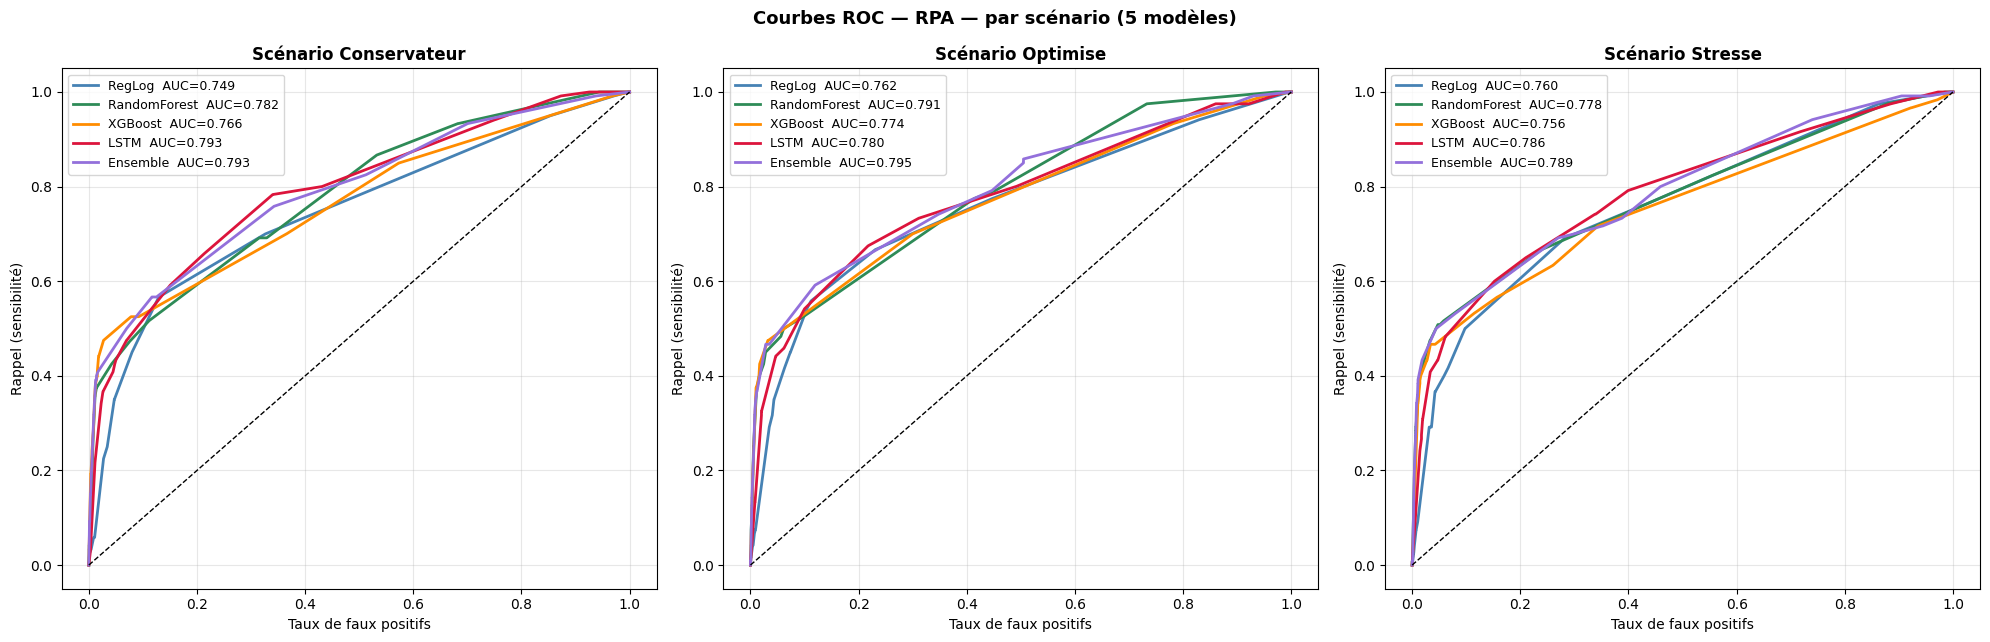

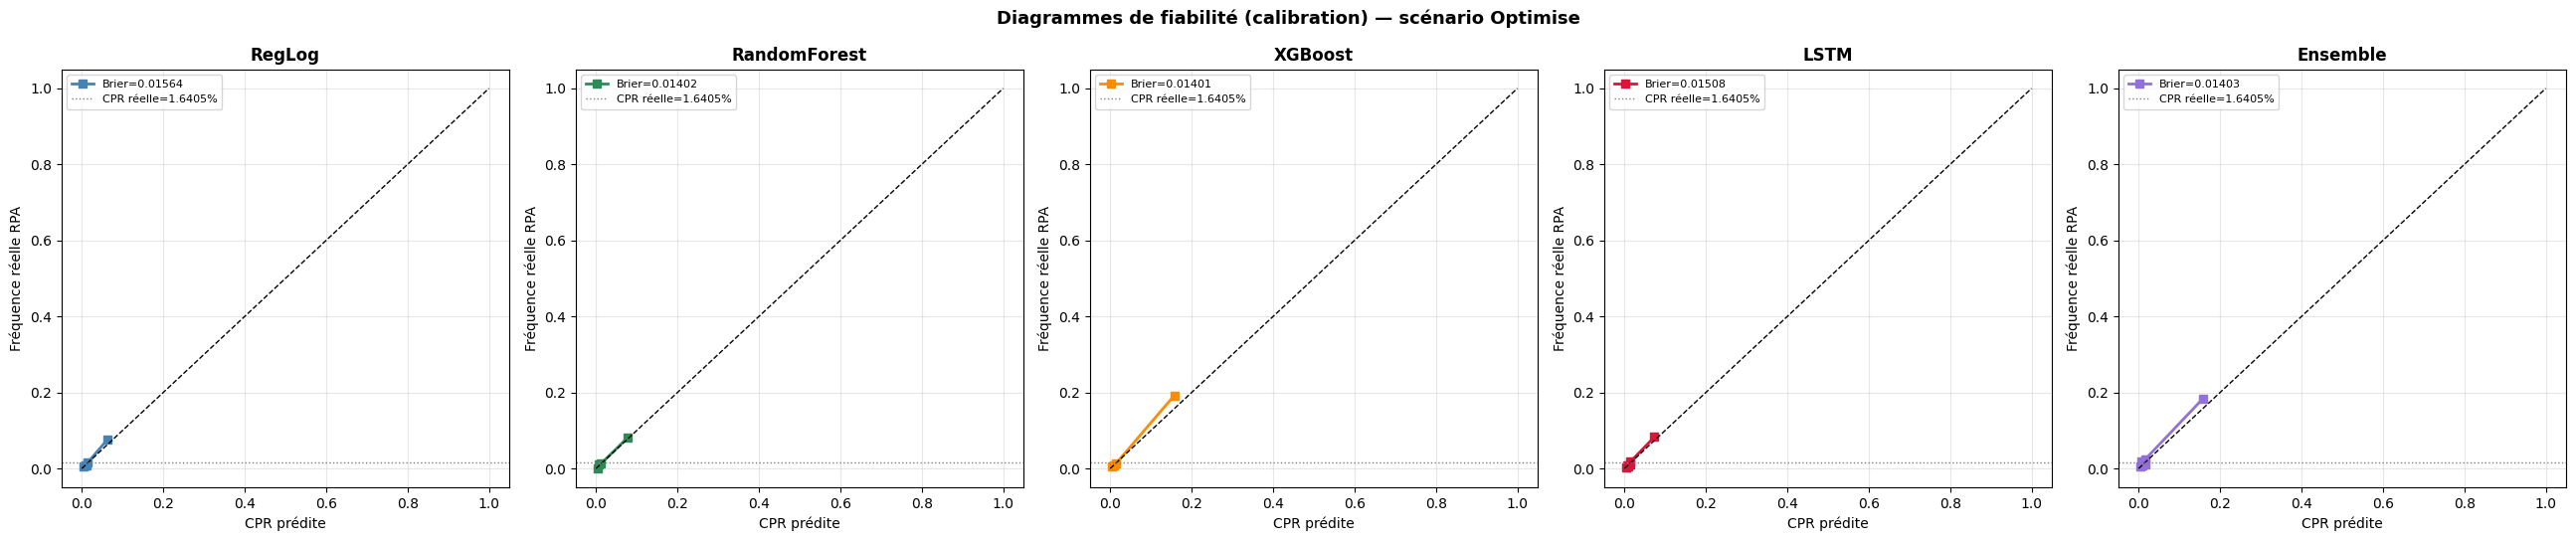

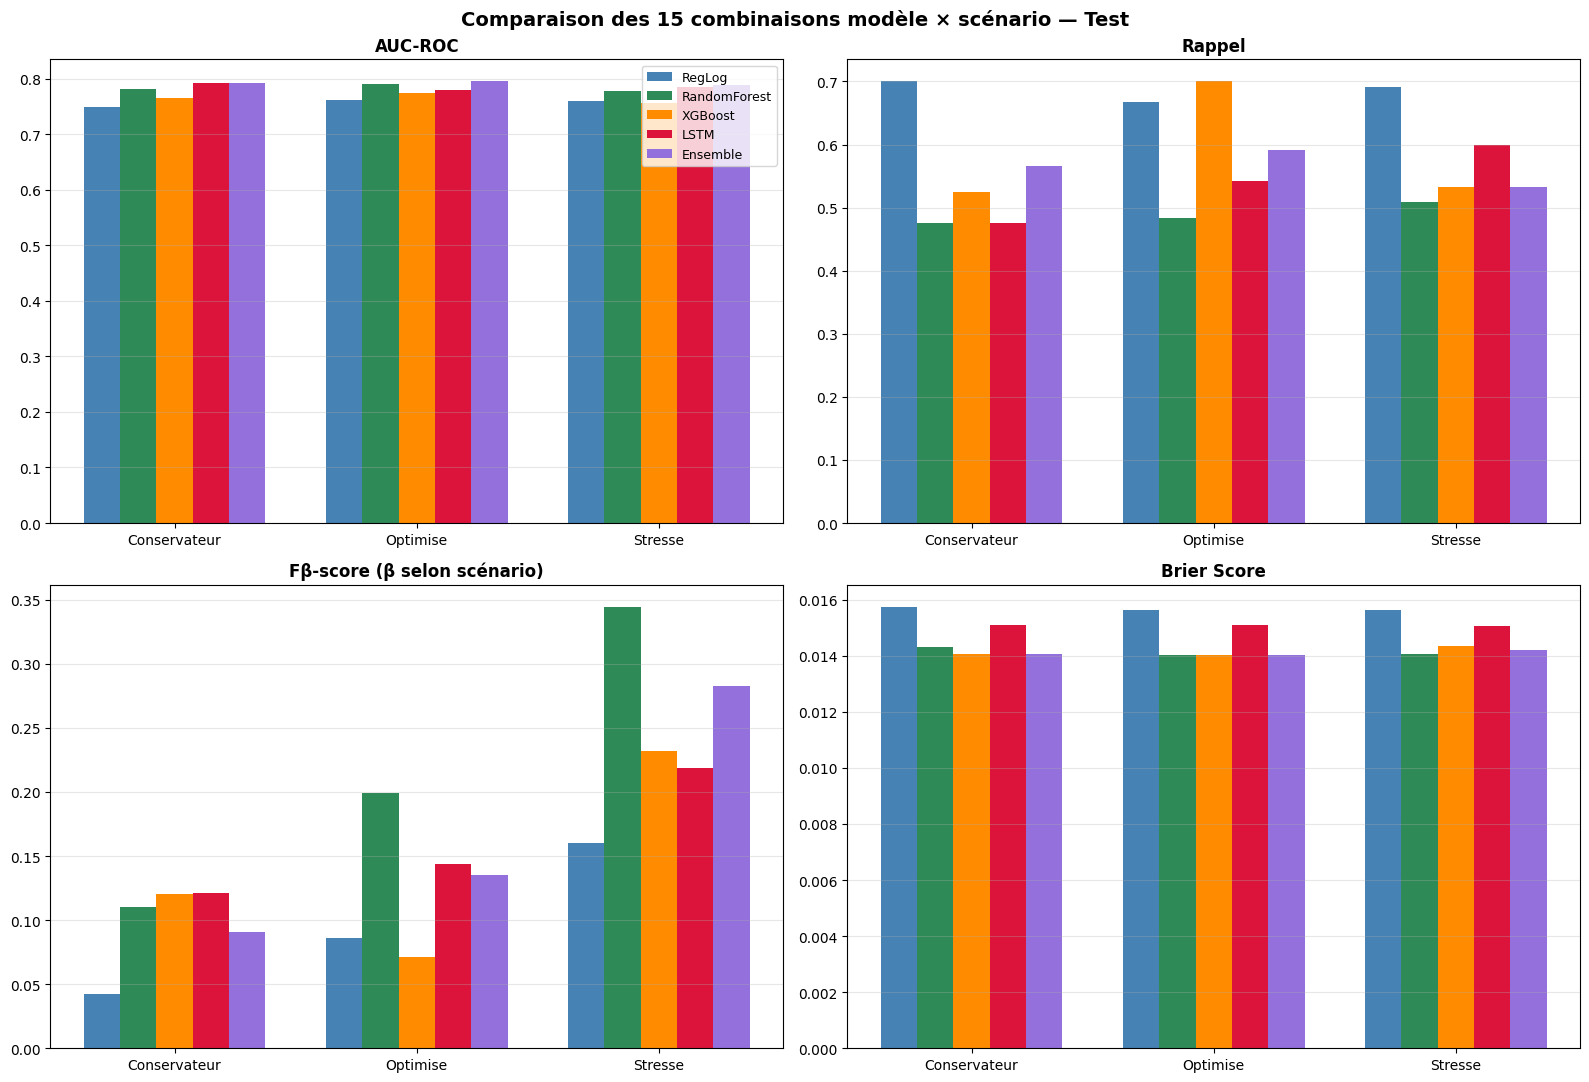

  3 figures sauvegardées : courbes ROC, calibration, comparaison 15 combinaisons
  BLOC 15 terminé


In [ ]:
# ##############################################################################
# BLOC 15 — GRAPHIQUES COMPARATIFS (ROC, calibration, synthèse en barres)
# ##############################################################################

separateur("15. GRAPHIQUES COMPARATIFS")

NOMS_MODELES   = ["RegLog", "RandomForest", "XGBoost", "LSTM", "Ensemble"]
COULEURS_MOD   = {"RegLog": "steelblue", "RandomForest": "seagreen",
                   "XGBoost": "darkorange", "LSTM": "crimson",
                   "Ensemble": "mediumpurple"}
STYLES_SCENAR  = {"Conservateur": ":", "Optimise": "-", "Stresse": "--"}

# ---- 15A. Courbes ROC — un panneau par scénario -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
fig.suptitle("Courbes ROC — RPA — par scénario (5 modèles)", fontweight="bold", fontsize=13)
for ax, sc in zip(axes, SCENARIOS.keys()):
    for mod in NOMS_MODELES:
        r = RESULTATS[(mod, sc)]
        fpr, tpr, _ = roc_curve(y_test, r["p_test"])
        ax.plot(fpr, tpr, color=COULEURS_MOD[mod], lw=2,
                label=f"{mod}  AUC={r['auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"Scénario {sc}", fontweight="bold")
    ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Rappel (sensibilité)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(chemin_sortie("RPA_courbes_roc_par_scenario.png"), dpi=150, bbox_inches="tight")
plt.show()

# ---- 15B. Reliability diagrams — scénario de référence ----------------------
fig, axes = plt.subplots(1, 5, figsize=(26, 5.5))
fig.suptitle(f"Diagrammes de fiabilité (calibration) — scénario {SCENARIO_REF}",
             fontweight="bold", fontsize=13)
for ax, mod in zip(axes, NOMS_MODELES):
    r = RESULTATS[(mod, SCENARIO_REF)]
    frac_pos, mean_pred = calibration_curve(y_test, r["p_test"], n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "s-", color=COULEURS_MOD[mod], lw=2,
            label=f"Brier={r['brier']:.5f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.axhline(y_test.mean(), color="gray", ls=":", lw=1, label=f"CPR réelle={y_test.mean():.4%}")
    ax.set_title(mod, fontweight="bold")
    ax.set_xlabel("CPR prédite"); ax.set_ylabel("Fréquence réelle RPA")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(chemin_sortie("RPA_calibration_reference.png"), dpi=150, bbox_inches="tight")
plt.show()

# ---- 15C. Comparaison en barres : AUC / Rappel / Fβ / Brier (15 combinaisons)
metriques_barres = ["auc", "Rappel", "Fbeta", "brier"]
titres_barres     = ["AUC-ROC", "Rappel", "Fβ-score (β selon scénario)", "Brier Score"]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Comparaison des 15 combinaisons modèle × scénario — Test", fontweight="bold", fontsize=14)
x = np.arange(len(SCENARIOS))
width = 0.15
for ax, met, titre in zip(axes.ravel(), metriques_barres, titres_barres):
    for i, mod in enumerate(NOMS_MODELES):
        vals = [RESULTATS[(mod, sc)][met] for sc in SCENARIOS.keys()]
        ax.bar(x + (i - 2) * width, vals, width, label=mod, color=COULEURS_MOD[mod])
    ax.set_xticks(x); ax.set_xticklabels(SCENARIOS.keys())
    ax.set_title(titre, fontweight="bold"); ax.grid(alpha=0.3, axis="y")
    if ax is axes.ravel()[0]:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(chemin_sortie("RPA_comparaison_15_combinaisons.png"), dpi=150, bbox_inches="tight")
plt.show()

print("  3 figures sauvegardées : courbes ROC, calibration, comparaison 15 combinaisons")
print("  BLOC 15 terminé")


  16. MATRICES DE CONFUSION — 15 COMBINAISONS


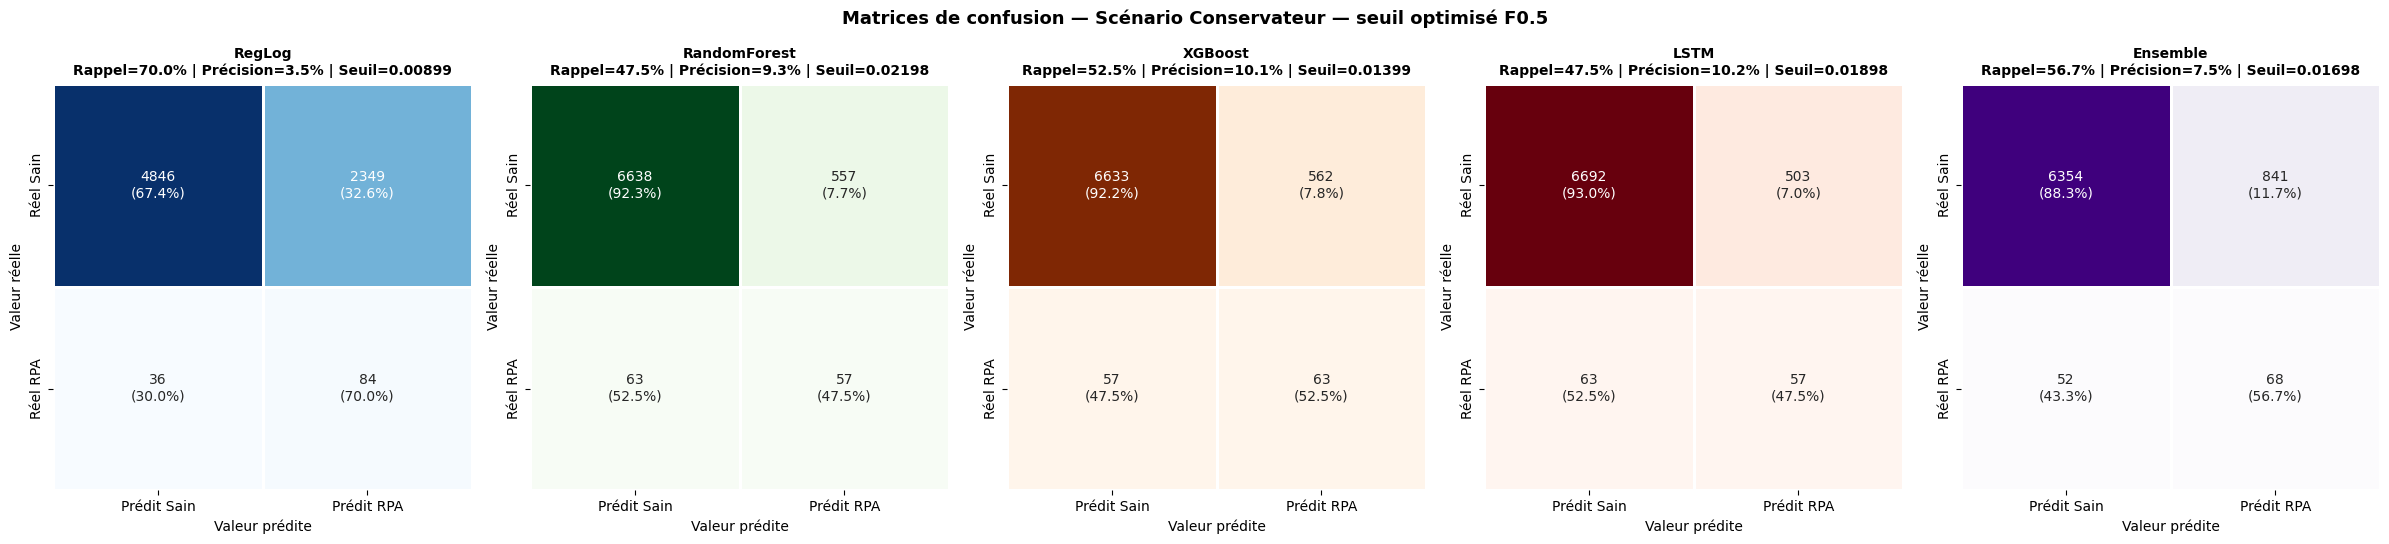

  Figure sauvegardée : RPA_matrices_confusion_Conservateur.png


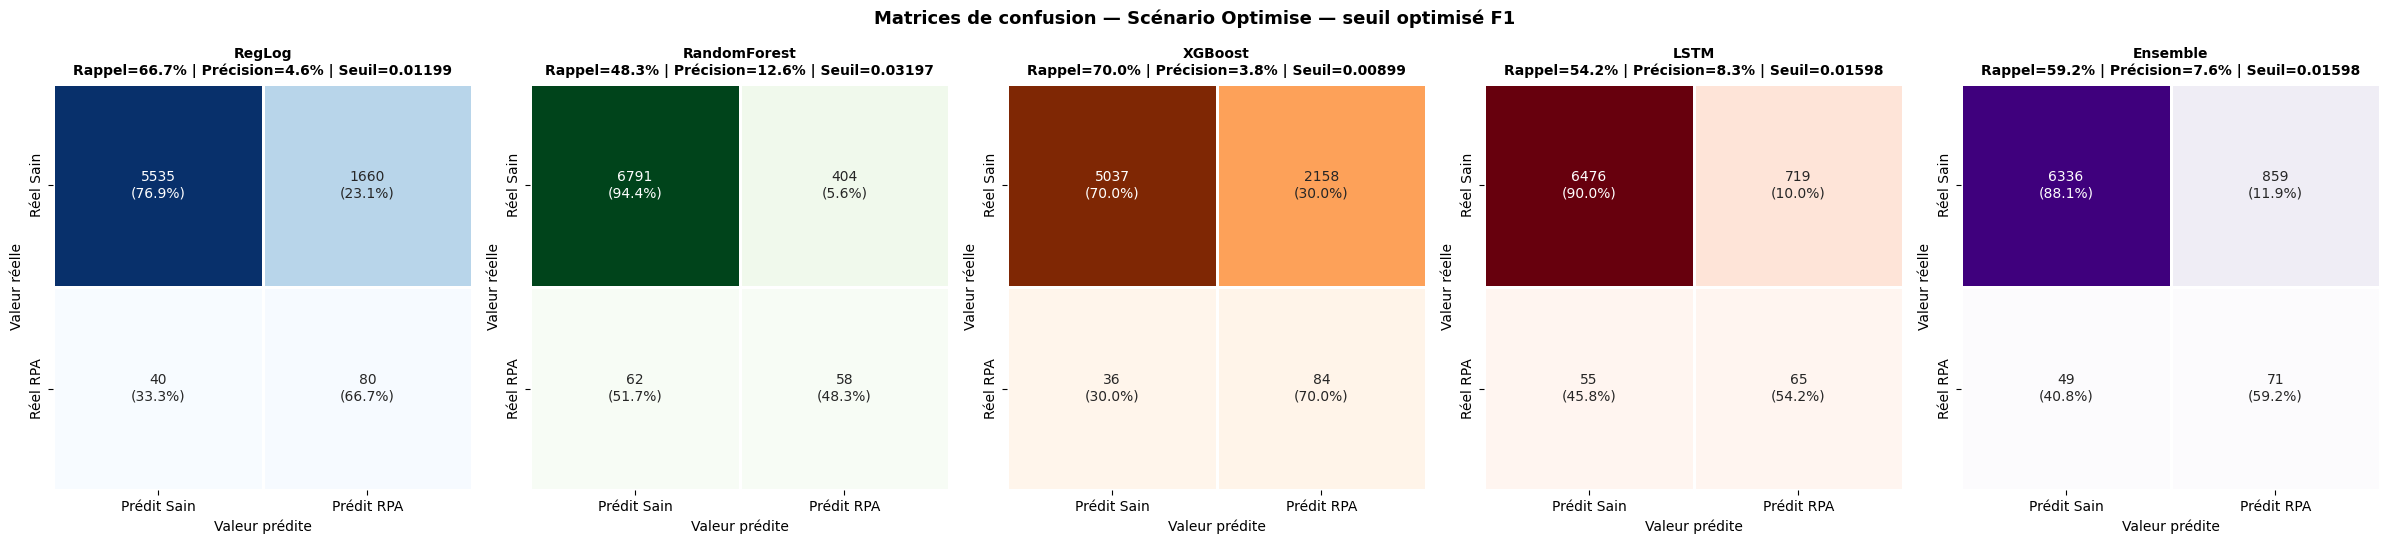

  Figure sauvegardée : RPA_matrices_confusion_Optimise.png


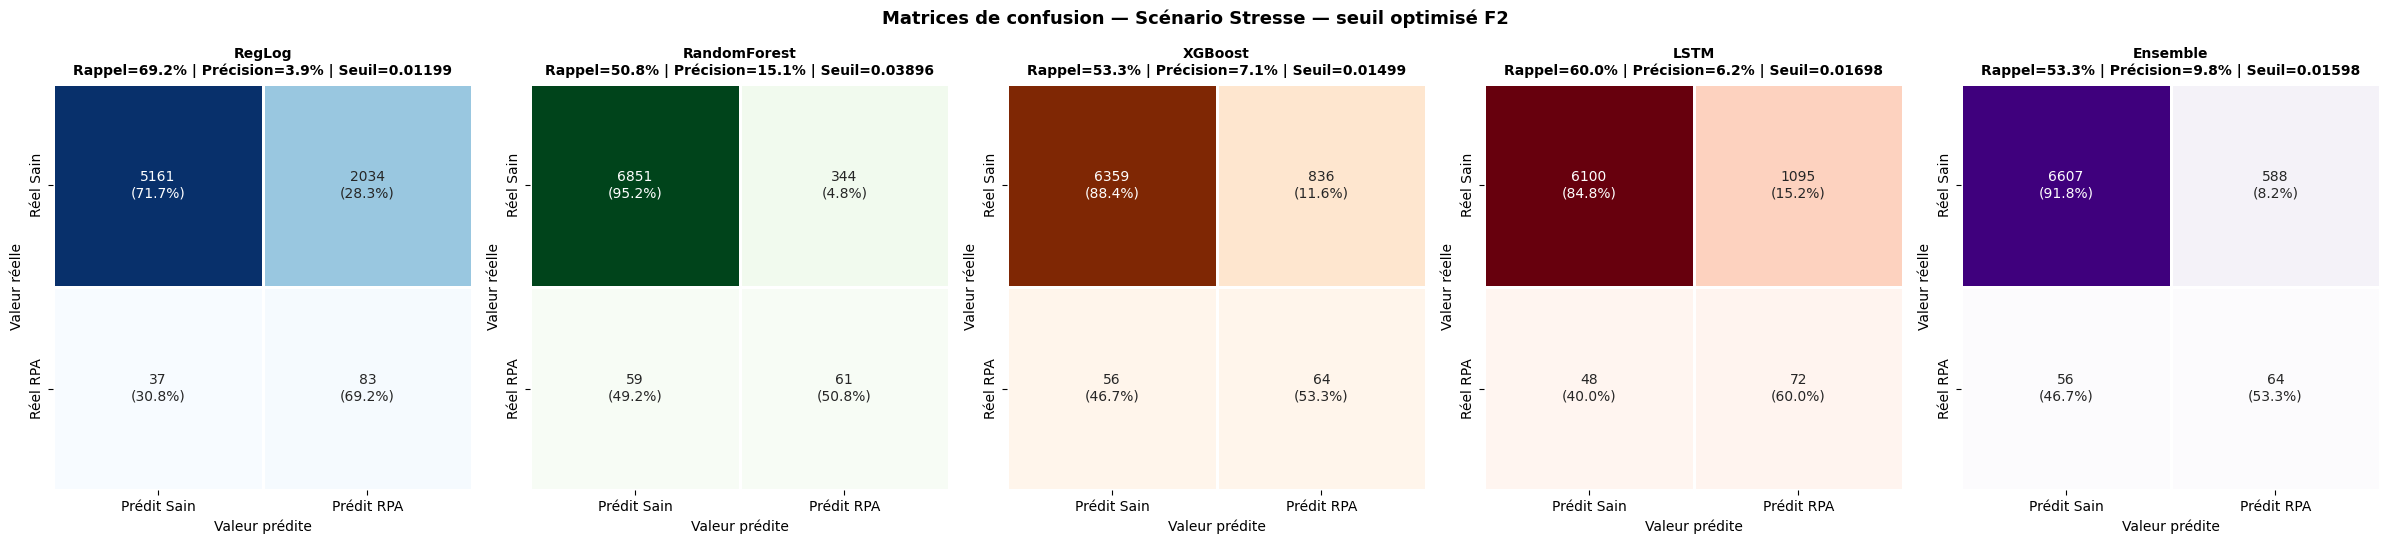

  Figure sauvegardée : RPA_matrices_confusion_Stresse.png
  BLOC 16 terminé


In [ ]:
# ##############################################################################
# BLOC 16 — MATRICES DE CONFUSION (5 modèles × 3 scénarios = 15 matrices)
# ##############################################################################

separateur("16. MATRICES DE CONFUSION — 15 COMBINAISONS")

CMAPS_MOD = {"RegLog": "Blues", "RandomForest": "Greens",
             "XGBoost": "Oranges", "LSTM": "Reds",
             "Ensemble": "Purples"}

for sc in SCENARIOS.keys():
    fig, axes = plt.subplots(1, 5, figsize=(24, 5.5))
    beta_sc = int(BETA_PAR_SCENARIO[sc]) if BETA_PAR_SCENARIO[sc] == int(BETA_PAR_SCENARIO[sc]) else BETA_PAR_SCENARIO[sc]
    fig.suptitle(f"Matrices de confusion — Scénario {sc} — seuil optimisé F{beta_sc}",
                 fontweight="bold", fontsize=13)
    for ax, mod in zip(axes, NOMS_MODELES):
        r = RESULTATS[(mod, sc)]
        titre = f"{mod}\nRappel={r['Rappel']:.1%} | Précision={r['Precision']:.1%} | Seuil={r['Seuil']}"
        afficher_matrice_confusion(ax, r["cm"], titre, cmap=CMAPS_MOD[mod])
    plt.tight_layout()
    plt.savefig(chemin_sortie(f"RPA_matrices_confusion_{sc}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figure sauvegardée : RPA_matrices_confusion_{sc}.png")

print("  BLOC 16 terminé")

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# TEST RAPIDE — AUC avec features brutes (sans rééquilibrage)
# ═════════════════════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

print("=" * 70)
print("  TEST RAPIDE — AUC features brutes (pas de SMOTE, pas de class_weight)")
print("=" * 70)

# RegLog simple, pas de trucage
model_test = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_test.fit(X_train_lr_raw, y_train_raw)
p_test_raw = model_test.predict_proba(X_test_lr)[:, 1]

auc_raw = roc_auc_score(y_test, p_test_raw)
print(f"\n  AUC brute (sans rééquilibrage) = {auc_raw:.4f}")

if auc_raw < 0.55:
    print("\n  🔴 PROBLÈME GRAVE : AUC < 0.55 = le modèle ne discrimine pas")
    print("  → Les features ne contiennent pas l'information nécessaire")
    print("  → Vérifiez la construction de Y_CPR et les features")
elif auc_raw < 0.65:
    print("\n  🟡 AUC faible (0.55-0.65) : difficile d'obtenir bon précision/rappel")
    print("  → Besoin de meilleures features ou plus de données")
else:
    print("\n  🟢 AUC acceptable (>0.65) : le problème vient du rééquilibrage/seuil")

  TEST RAPIDE — AUC features brutes (pas de SMOTE, pas de class_weight)

  AUC brute (sans rééquilibrage) = 0.7603

  🟢 AUC acceptable (>0.65) : le problème vient du rééquilibrage/seuil


In [ ]:
# BLOC 17 — COURBES D'APPRENTISSAGE LSTM (loss / AUC, train vs val)
# ##############################################################################

separateur("17. COURBES D'APPRENTISSAGE LSTM")

fig, axes = plt.subplots(2, 3, figsize=(19, 9))
fig.suptitle("Courbes d'apprentissage du LSTM hybride — 3 scénarios", fontweight="bold", fontsize=13)
for j, sc in enumerate(SCENARIOS.keys()):
    h = historiques_lstm[sc]
    axes[0, j].plot(h["loss"], label="Train", color="steelblue")
    axes[0, j].plot(h["val_loss"], label="Validation", color="darkorange")
    axes[0, j].set_title(f"{sc} — Loss (binary cross-entropy)", fontweight="bold")
    axes[0, j].set_xlabel("Époque"); axes[0, j].legend(fontsize=8); axes[0, j].grid(alpha=0.3)
    axes[1, j].plot(h["auc"], label="Train", color="steelblue")
    axes[1, j].plot(h["val_auc"], label="Validation", color="darkorange")
    axes[1, j].set_title(f"{sc} — AUC-ROC", fontweight="bold")
    axes[1, j].set_xlabel("Époque"); axes[1, j].legend(fontsize=8); axes[1, j].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(chemin_sortie("RPA_LSTM_courbes_apprentissage.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  BLOC 17 terminé")

In [ ]:
# ##############################################################################
# BLOC 18 — TABLEAU DE SYNTHÈSE COMPLET + SÉLECTION DU MEILLEUR MODÈLE
# (VERSION CORRIGÉE — Taux de Y prédit affiché)
# ##############################################################################

# ── 1. GARDE-FOU : définir separateur si absent ─────────────────────────────
if "separateur" not in dir():
    def separateur(titre, niveau=1):
        if niveau == 1:
            print("\n" + "=" * 78)
            print(f"  {titre}")
            print("=" * 78)
        else:
            print(f"\n  --- {titre} ---")

# ── 2. GARDE-FOU : vérifier que RESULTATS existe ────────────────────────────
if "RESULTATS" not in dir() or not RESULTATS:
    print("=" * 78)
    print("  ⚠ GARDE-FOU : RESULTATS est vide ou inexistant.")
    print("=" * 78)
    print("""
  Ce bloc nécessite que les modèles soient déjà entraînés (BLOCs 11-14).

  Solutions :
  1. Ré-exécute les BLOCs 11 → 14 (entraînement RegLog / RF / XGB / LSTM)
  2. Ou charge les résultats sauvegardés si disponibles :
  """)

    # Tentative de chargement depuis fichiers sauvegardés
    import os, json
    chemin_resultats = os.path.join(DOSSIER_SORTIE, "RPA_synthese_12_combinaisons.csv") if "DOSSIER_SORTIE" in dir() else "./RPA_synthese_12_combinaisons.csv"

    if os.path.exists(chemin_resultats):
        print(f"  ✔ Fichier trouvé : {chemin_resultats}")
        print("  Charge-le manuellement avec : df = pd.read_csv('...')")
    else:
        print(f"  ✗ Aucun fichier de sauvegarde trouvé.")

    raise RuntimeError(
        "Ré-exécute les BLOCs 11-14 avant le BLOC 18, ou assure-toi que "
        "RESULTATS est défini dans l'environnement."
    )

# ── 3. GARDE-FOU : vérifier les autres variables nécessaires ────────────────
variables_requises = {
    "y_val": "BLOC 8 (split train/val/test)",
    "y_test": "BLOC 8 (split train/val/test)",
    "NOMS_MODELES": "BLOC 10 ou 15",
    "SCENARIOS": "BLOC 1 (paramètres globaux)",
}

manquantes = [(v, src) for v, src in variables_requises.items() if v not in dir()]
if manquantes:
    print("  ❌ Variables manquantes :")
    for v, src in manquantes:
        print(f"      {v} → {src}")
    raise RuntimeError("Ré-exécute les blocs précédents avant le BLOC 18.")

# ── 4. EXÉCUTION PRINCIPALE ─────────────────────────────────────────────────
separateur("18. SYNTHÈSE COMPLÈTE + SÉLECTION DU MEILLEUR MODÈLE")

lignes = []
for mod in NOMS_MODELES:
    for sc in SCENARIOS.keys():
        # Vérifier que la clé existe dans RESULTATS
        if (mod, sc) not in RESULTATS:
            print(f"  ⚠ Résultat manquant pour ({mod}, {sc}) — ignoré")
            continue

        r = RESULTATS[(mod, sc)]

        # Vérifier que p_val existe pour calculer AUC validation
        if "p_val" not in r or "p_test" not in r:
            print(f"  ⚠ Probas manquantes pour ({mod}, {sc}) — ignoré")
            continue

        auc_val = roc_auc_score(y_val, r["p_val"])

        lignes.append({
            "Modele": mod, "Scenario": sc,
            "AUC_validation": round(auc_val, 4),
            "AUC_test": round(r["auc"], 4),
            "AUC_IC95_bas": round(r["auc_lo"], 4) if not np.isnan(r.get("auc_lo", np.nan)) else np.nan,
            "AUC_IC95_haut": round(r["auc_hi"], 4) if not np.isnan(r.get("auc_hi", np.nan)) else np.nan,
            "Fbeta_test": r.get("Fbeta", 0),
            "beta_utilise": r.get("beta_utilise", BETA_FSCORE),
            "Rappel_test": r.get("Rappel", 0),
            "Precision_test": r.get("Precision", 0),
            "Brier_test": round(r["brier"], 6),
            "VP": r.get("VP", 0),
            "FP": r.get("FP", 0),
            "FN": r.get("FN", 0),
            "Seuil": r.get("Seuil", 0.5),
            "CPR_predite": round(r.get("cpr_pred", 0), 6),
            "CPR_reelle": round(r.get("cpr_reelle", 0), 6),
        })

if not lignes:
    raise RuntimeError("Aucun résultat valide trouvé dans RESULTATS.")

df_synthese_finale = pd.DataFrame(lignes).sort_values("AUC_validation", ascending=False).reset_index(drop=True)

print("\n  TABLEAU COMPLET — COMBINAISONS (triées par AUC validation décroissante) :\n")
print(df_synthese_finale.to_string(index=False))

# ── 5. SÉLECTION DU CHAMPION ───────────────────────────────────────────────
meilleur = df_synthese_finale.iloc[0]
MEILLEUR_MODELE   = meilleur["Modele"]
MEILLEUR_SCENARIO = meilleur["Scenario"]

# ── 6. CALCUL DU TAUX DE Y PRÉDIT PAR LE CHAMPION ─────────────────────────
print(f"\n  {'='*74}")
print("  MEILLEUR MODÈLE (sélection objective sur AUC validation)")
print(f"  {'='*74}")

# Récupérer les probas et seuil du champion
p_test_champion = RESULTATS[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]["p_test"]
seuil_champion = RESULTATS[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]["Seuil"]

# Y prédit binaire (classification)
y_pred_champion = (p_test_champion >= seuil_champion).astype(int)

# Taux de Y prédit
TAUX_Y_PREDIT_CHAMPION = y_pred_champion.mean()
TAUX_Y_REEL_TEST = y_test.mean()
N_Y_PREDITS = y_pred_champion.sum()
N_TOTAL_TEST = len(y_pred_champion)

# Comparaison avec la CPR prédite (moyenne des probas)
CPR_PREDITE_CHAMPION = p_test_champion.mean()

print(f"""
    Modèle    : {MEILLEUR_MODELE}
    Scénario  : {MEILLEUR_SCENARIO}
    AUC val   : {meilleur['AUC_validation']:.4f}
    AUC test  : {meilleur['AUC_test']:.4f}
    Rappel    : {meilleur['Rappel_test']:.4f}
    F{int(meilleur['beta_utilise'])}-score   : {meilleur['Fbeta_test']:.4f}

  {'='*74}
  ★ TAUX DE Y PRÉDIT PAR LE CHAMPION (TEST) :
  {'='*74}
    Y=1 (RPA) prédits : {N_Y_PREDITS:,} / {N_TOTAL_TEST:,}
    Taux Y prédit (classification) : {TAUX_Y_PREDIT_CHAMPION:.4%}
    Taux Y réel (test)             : {TAUX_Y_REEL_TEST:.4%}
    Écart prédit vs réel           : {(TAUX_Y_PREDIT_CHAMPION - TAUX_Y_REEL_TEST):+.4%}

    CPR prédite (moyenne probas)   : {CPR_PREDITE_CHAMPION:.4%}
    CPR vintage référence            : {CPR_VINTAGE:.4%}
    CPR observée (test)              : {CPR_OBSERVEE:.4%}
  {'='*74}
""")

# ── 7. COMMENTAIRE SUR LE CHAMPION ─────────────────────────────────────────
if MEILLEUR_MODELE == "LSTM":
    print("  Le LSTM hybride (accès aux trajectoires mensuelles + attention)")
    print("  ressort comme meilleur modèle — conforme à l'avantage informationnel")
    print("  structurel attendu, confirmé ici par les métriques réelles.")
else:
    print(f"  Sur cette exécution, c'est {MEILLEUR_MODELE} qui l'emporte. Pistes pour")
    print("  aider le LSTM à mieux exploiter son avantage informationnel :")
    print("  augmenter LSTM_EPOCHS, élargir FENETRE_SEQ, ajuster class_weight_mult,")
    print("  ou enrichir FEATURES_SEQ (BLOC 5BIS) avec d'autres signaux mensuels.")

# ── 8. SAUVEGARDE ──────────────────────────────────────────────────────────
df_synthese_finale.to_csv(chemin_sortie("RPA_synthese_12_combinaisons.csv"), index=False)
print("\n  ✔ RPA_synthese_12_combinaisons.csv sauvegardé")

# Sauvegarde du taux Y prédit dans un fichier récap
df_taux_y = pd.DataFrame([{
    "Modele": MEILLEUR_MODELE,
    "Scenario": MEILLEUR_SCENARIO,
    "Taux_Y_pred": round(TAUX_Y_PREDIT_CHAMPION, 6),
    "Taux_Y_reel": round(TAUX_Y_REEL_TEST, 6),
    "Ecart_Y": round(TAUX_Y_PREDIT_CHAMPION - TAUX_Y_REEL_TEST, 6),
    "CPR_predite": round(CPR_PREDITE_CHAMPION, 6),
    "CPR_vintage": round(CPR_VINTAGE, 6),
    "CPR_observee": round(CPR_OBSERVEE, 6),
    "Seuil": round(seuil_champion, 5),
    "N_Y_predits": N_Y_PREDITS,
    "N_total": N_TOTAL_TEST
}])
df_taux_y.to_csv(chemin_sortie("RPA_taux_Y_champion.csv"), index=False)
print("  ✔ RPA_taux_Y_champion.csv sauvegardé")

print("  BLOC 18 terminé")# ##############################################################################
# BLOC 18 — TABLEAU DE SYNTHÈSE COMPLET + SÉLECTION DU MEILLEUR MODÈLE
# (VERSION CORRIGÉE — Taux de Y prédit affiché)
# ##############################################################################

# ── 1. GARDE-FOU : définir separateur si absent ─────────────────────────────
if "separateur" not in dir():
    def separateur(titre, niveau=1):
        if niveau == 1:
            print("\n" + "=" * 78)
            print(f"  {titre}")
            print("=" * 78)
        else:
            print(f"\n  --- {titre} ---")

# ── 2. GARDE-FOU : vérifier que RESULTATS existe ────────────────────────────
if "RESULTATS" not in dir() or not RESULTATS:
    print("=" * 78)
    print("  ⚠ GARDE-FOU : RESULTATS est vide ou inexistant.")
    print("=" * 78)
    print("""
  Ce bloc nécessite que les modèles soient déjà entraînés (BLOCs 11-14).

  Solutions :
  1. Ré-exécute les BLOCs 11 → 14 (entraînement RegLog / RF / XGB / LSTM)
  2. Ou charge les résultats sauvegardés si disponibles :
  """)

    # Tentative de chargement depuis fichiers sauvegardés
    import os, json
    chemin_resultats = os.path.join(DOSSIER_SORTIE, "RPA_synthese_12_combinaisons.csv") if "DOSSIER_SORTIE" in dir() else "./RPA_synthese_12_combinaisons.csv"

    if os.path.exists(chemin_resultats):
        print(f"  ✔ Fichier trouvé : {chemin_resultats}")
        print("  Charge-le manuellement avec : df = pd.read_csv('...')")
    else:
        print(f"  ✗ Aucun fichier de sauvegarde trouvé.")

    raise RuntimeError(
        "Ré-exécute les BLOCs 11-14 avant le BLOC 18, ou assure-toi que "
        "RESULTATS est défini dans l'environnement."
    )

# ── 3. GARDE-FOU : vérifier les autres variables nécessaires ────────────────
variables_requises = {
    "y_val": "BLOC 8 (split train/val/test)",
    "y_test": "BLOC 8 (split train/val/test)",
    "NOMS_MODELES": "BLOC 10 ou 15",
    "SCENARIOS": "BLOC 1 (paramètres globaux)",
}

manquantes = [(v, src) for v, src in variables_requises.items() if v not in dir()]
if manquantes:
    print("  ❌ Variables manquantes :")
    for v, src in manquantes:
        print(f"      {v} → {src}")
    raise RuntimeError("Ré-exécute les blocs précédents avant le BLOC 18.")

# ── 4. EXÉCUTION PRINCIPALE ─────────────────────────────────────────────────
separateur("18. SYNTHÈSE COMPLÈTE + SÉLECTION DU MEILLEUR MODÈLE")

lignes = []
for mod in NOMS_MODELES:
    for sc in SCENARIOS.keys():
        # Vérifier que la clé existe dans RESULTATS
        if (mod, sc) not in RESULTATS:
            print(f"  ⚠ Résultat manquant pour ({mod}, {sc}) — ignoré")
            continue

        r = RESULTATS[(mod, sc)]

        # Vérifier que p_val existe pour calculer AUC validation
        if "p_val" not in r or "p_test" not in r:
            print(f"  ⚠ Probas manquantes pour ({mod}, {sc}) — ignoré")
            continue

        auc_val = roc_auc_score(y_val, r["p_val"])

        lignes.append({
            "Modele": mod, "Scenario": sc,
            "AUC_validation": round(auc_val, 4),
            "AUC_test": round(r["auc"], 4),
            "AUC_IC95_bas": round(r["auc_lo"], 4) if not np.isnan(r.get("auc_lo", np.nan)) else np.nan,
            "AUC_IC95_haut": round(r["auc_hi"], 4) if not np.isnan(r.get("auc_hi", np.nan)) else np.nan,
            "Fbeta_test": r.get("Fbeta", 0),
            "beta_utilise": r.get("beta_utilise", BETA_FSCORE),
            "Rappel_test": r.get("Rappel", 0),
            "Precision_test": r.get("Precision", 0),
            "Brier_test": round(r["brier"], 6),
            "VP": r.get("VP", 0),
            "FP": r.get("FP", 0),
            "FN": r.get("FN", 0),
            "Seuil": r.get("Seuil", 0.5),
            "CPR_predite": round(r.get("cpr_pred", 0), 6),
            "CPR_reelle": round(r.get("cpr_reelle", 0), 6),
        })

if not lignes:
    raise RuntimeError("Aucun résultat valide trouvé dans RESULTATS.")

df_synthese_finale = pd.DataFrame(lignes).sort_values("AUC_validation", ascending=False).reset_index(drop=True)

print("\n  TABLEAU COMPLET — COMBINAISONS (triées par AUC validation décroissante) :\n")
print(df_synthese_finale.to_string(index=False))

# ── 5. SÉLECTION DU CHAMPION ───────────────────────────────────────────────
meilleur = df_synthese_finale.iloc[0]
MEILLEUR_MODELE   = meilleur["Modele"]
MEILLEUR_SCENARIO = meilleur["Scenario"]

# ── 6. CALCUL DU TAUX DE Y PRÉDIT PAR LE CHAMPION ─────────────────────────
print(f"\n  {'='*74}")
print("  MEILLEUR MODÈLE (sélection objective sur AUC validation)")
print(f"  {'='*74}")

# Récupérer les probas et seuil du champion
p_test_champion = RESULTATS[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]["p_test"]
seuil_champion = RESULTATS[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]["Seuil"]

# Y prédit binaire (classification)
y_pred_champion = (p_test_champion >= seuil_champion).astype(int)

# Taux de Y prédit
TAUX_Y_PREDIT_CHAMPION = y_pred_champion.mean()
TAUX_Y_REEL_TEST = y_test.mean()
N_Y_PREDITS = y_pred_champion.sum()
N_TOTAL_TEST = len(y_pred_champion)

# Comparaison avec la CPR prédite (moyenne des probas)
CPR_PREDITE_CHAMPION = p_test_champion.mean()

print(f"""
    Modèle    : {MEILLEUR_MODELE}
    Scénario  : {MEILLEUR_SCENARIO}
    AUC val   : {meilleur['AUC_validation']:.4f}
    AUC test  : {meilleur['AUC_test']:.4f}
    Rappel    : {meilleur['Rappel_test']:.4f}
    F{int(meilleur['beta_utilise'])}-score   : {meilleur['Fbeta_test']:.4f}

  {'='*74}
  ★ TAUX DE Y PRÉDIT PAR LE CHAMPION (TEST) :
  {'='*74}
    Y=1 (RPA) prédits : {N_Y_PREDITS:,} / {N_TOTAL_TEST:,}
    Taux Y prédit (classification) : {TAUX_Y_PREDIT_CHAMPION:.4%}
    Taux Y réel (test)             : {TAUX_Y_REEL_TEST:.4%}
    Écart prédit vs réel           : {(TAUX_Y_PREDIT_CHAMPION - TAUX_Y_REEL_TEST):+.4%}

    CPR prédite (moyenne probas)   : {CPR_PREDITE_CHAMPION:.4%}
    CPR vintage référence            : {CPR_VINTAGE:.4%}
    CPR observée (test)              : {CPR_OBSERVEE:.4%}
  {'='*74}
""")

# ── 7. COMMENTAIRE SUR LE CHAMPION ─────────────────────────────────────────
if MEILLEUR_MODELE == "LSTM":
    print("  Le LSTM hybride (accès aux trajectoires mensuelles + attention)")
    print("  ressort comme meilleur modèle — conforme à l'avantage informationnel")
    print("  structurel attendu, confirmé ici par les métriques réelles.")
else:
    print(f"  Sur cette exécution, c'est {MEILLEUR_MODELE} qui l'emporte. Pistes pour")
    print("  aider le LSTM à mieux exploiter son avantage informationnel :")
    print("  augmenter LSTM_EPOCHS, élargir FENETRE_SEQ, ajuster class_weight_mult,")
    print("  ou enrichir FEATURES_SEQ (BLOC 5BIS) avec d'autres signaux mensuels.")

# ── 8. SAUVEGARDE ──────────────────────────────────────────────────────────
df_synthese_finale.to_csv(chemin_sortie("RPA_synthese_12_combinaisons.csv"), index=False)
print("\n  ✔ RPA_synthese_12_combinaisons.csv sauvegardé")

# Sauvegarde du taux Y prédit dans un fichier récap
df_taux_y = pd.DataFrame([{
    "Modele": MEILLEUR_MODELE,
    "Scenario": MEILLEUR_SCENARIO,
    "Taux_Y_pred": round(TAUX_Y_PREDIT_CHAMPION, 6),
    "Taux_Y_reel": round(TAUX_Y_REEL_TEST, 6),
    "Ecart_Y": round(TAUX_Y_PREDIT_CHAMPION - TAUX_Y_REEL_TEST, 6),
    "CPR_predite": round(CPR_PREDITE_CHAMPION, 6),
    "CPR_vintage": round(CPR_VINTAGE, 6),
    "CPR_observee": round(CPR_OBSERVEE, 6),
    "Seuil": round(seuil_champion, 5),
    "N_Y_predits": N_Y_PREDITS,
    "N_total": N_TOTAL_TEST
}])
df_taux_y.to_csv(chemin_sortie("RPA_taux_Y_champion.csv"), index=False)
print("  ✔ RPA_taux_Y_champion.csv sauvegardé")

print("  BLOC 18 terminé")


  18. SYNTHÈSE COMPLÈTE + SÉLECTION DU MEILLEUR MODÈLE

  TABLEAU COMPLET — COMBINAISONS (triées par AUC validation décroissante) :

      Modele     Scenario  AUC_validation  AUC_test  AUC_IC95_bas  AUC_IC95_haut  Fbeta_test  beta_utilise  Rappel_test  Precision_test  Brier_test  VP   FP  FN   Seuil  CPR_predite  CPR_reelle
    Ensemble      Stresse          0.8025    0.7891        0.7414         0.8370      0.2827           2.0       0.5333          0.0982    0.014190  64  588  56 0.01598     0.015253    0.016405
    Ensemble     Optimise          0.8022    0.7953        0.7470         0.8470      0.1352           1.0       0.5917          0.0763    0.014031  71  859  49 0.01598     0.015181    0.016405
    Ensemble Conservateur          0.7913    0.7926        0.7454         0.8427      0.0905           0.5       0.5667          0.0748    0.014044  68  841  52 0.01698     0.015331    0.016405
        LSTM      Stresse          0.7877    0.7856        0.7394         0.8329      0.21

In [ ]:
# ##############################################################################
# BLOC 19 — EXPORT EXCEL MULTI-ONGLETS
# ##############################################################################

separateur("19. EXPORT EXCEL")

# Scoring complet (train+val+test) avec le MEILLEUR modèle/scénario
modele_final = MODELES_ENTRAINES[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]

def scorer_static(d, modele_nom=MEILLEUR_MODELE, scenario=MEILLEUR_SCENARIO):
    modele = MODELES_ENTRAINES[(modele_nom, scenario)]
    if modele_nom == "RegLog":
        return modele.predict_proba(build_lr_matrix(d))[:, 1]
    elif modele_nom in ("RandomForest", "XGBoost"):
        return modele.predict_proba(preparer_tree(d))[:, 1]
    elif modele_nom == "Ensemble":
        # Calcul des 4 probabilités de base
        p_reglog = MODELES_ENTRAINES[("RegLog", scenario)].predict_proba(build_lr_matrix(d))[:, 1]
        p_rf = MODELES_ENTRAINES[("RandomForest", scenario)].predict_proba(preparer_tree(d))[:, 1]
        p_xgb = MODELES_ENTRAINES[("XGBoost", scenario)].predict_proba(preparer_tree(d))[:, 1]
        if "ie_affaire" in d.columns:
            ids_d = d["ie_affaire"].values
            X_seq_d = construire_sequences(df_avant, ids_d)
            X_seq_d = normaliser_seq(X_seq_d)
            X_static_d = build_lr_matrix(d)
            p_lstm = MODELES_ENTRAINES[("LSTM", scenario)].predict(
                {"seq_input": X_seq_d, "static_input": X_static_d}, verbose=0).ravel()
        else:
            p_lstm = (p_reglog + p_rf + p_xgb) / 3.0
        X_meta = np.column_stack([p_reglog, p_rf, p_xgb, p_lstm])
        return modele.predict_proba(X_meta)[:, 1]
    return None

if MEILLEUR_MODELE == "LSTM":
    ids_full = np.concatenate([ids_train, ids_val, ids_test])
    X_seq_full = construire_sequences(df_avant, ids_full)
    X_seq_full = normaliser_seq(X_seq_full)
    X_static_full = np.concatenate([X_train_static_raw, X_val_static, X_test_static], axis=0)
    cpr_full = modele_final.predict(
        {"seq_input": X_seq_full, "static_input": X_static_full}, verbose=0).ravel()
elif MEILLEUR_MODELE == "Ensemble":
    cpr_full = np.concatenate([
        scorer_static(df_train_raw, "Ensemble", MEILLEUR_SCENARIO),
        scorer_static(df_val_raw, "Ensemble", MEILLEUR_SCENARIO),
        scorer_static(df_test_raw, "Ensemble", MEILLEUR_SCENARIO)
    ])
    ids_full = np.concatenate([ids_train, ids_val, ids_test])
else:
    cpr_full = np.concatenate([scorer_static(df_train_raw), scorer_static(df_val_raw),
                                scorer_static(df_test_raw)])
    ids_full = np.concatenate([ids_train, ids_val, ids_test])

df_scoring = pd.DataFrame({
    "ie_affaire": ids_full,
    "Y_reel": np.concatenate([y_train_raw, y_val, y_test]),
    "Ensemble": ["TRAIN"]*len(y_train_raw) + ["VAL"]*len(y_val) + ["TEST"]*len(y_test),
    "CPR_predite": cpr_full,
})
P33, P67, P90 = df_scoring["CPR_predite"].quantile([0.33, 0.67, 0.90])
df_scoring["Segment_CPR"] = pd.cut(df_scoring["CPR_predite"], bins=[0, P33, P67, P90, 1.0],
                                    labels=["FAIBLE","MODERE","ELEVE","TRES ELEVE"], include_lowest=True)

with pd.ExcelWriter(chemin_sortie("RPA_resultats_complets.xlsx"), engine="openpyxl") as writer:
    df_synthese_finale.to_excel(writer, sheet_name="1_Synthese_15_combinaisons", index=False)
    df_scoring.to_excel(writer, sheet_name="2_Scoring_meilleur_modele", index=False)
    df_synthese.to_excel(writer, sheet_name="3_Selection_features", index=False)
    coef_df_ref.to_excel(writer, sheet_name="4_Coefficients_RegLog", index=False)
    pd.concat([
        imp_rf_ref.assign(Modele="RandomForest"),
        imp_xgb_ref.assign(Modele="XGBoost"),
    ]).to_excel(writer, sheet_name="5_Importances_RF_XGB", index=False)
    pd.DataFrame([
        {"Scenario": sc, "Modele": m, **SCENARIOS[sc][k]}
        for sc in SCENARIOS for m, k in [("RegLog","reglog"),("RandomForest","rf"),
                                          ("XGBoost","xgb"),("LSTM","lstm")]
    ] + [
        {"Scenario": sc, "Modele": "Ensemble", "type": "stacking_lr",
         "C": 1.0, "smote_ratio": 0.0}
        for sc in SCENARIOS
    ]).to_excel(writer, sheet_name="6_Parametres_scenarios", index=False)

print("  RPA_resultats_complets.xlsx exporté (6 onglets)")
print("  BLOC 19 terminé")


  19. EXPORT EXCEL
  RPA_resultats_complets.xlsx exporté (6 onglets)
  BLOC 19 terminé


In [ ]:
# BLOC 20 — SAUVEGARDE DES MODÈLES (pour l'application de scoring, app.py)
# ##############################################################################

separateur("20. SAUVEGARDE DES MODÈLES")

DOSSIER_MODELES = chemin_sortie("modeles_rpa")
os.makedirs(DOSSIER_MODELES, exist_ok=True)

for sc in SCENARIOS.keys():
    joblib.dump(MODELES_ENTRAINES[("RegLog", sc)], f"{DOSSIER_MODELES}/reglog_{sc}.pkl")
    joblib.dump(MODELES_ENTRAINES[("RandomForest", sc)], f"{DOSSIER_MODELES}/rf_{sc}.pkl")
    joblib.dump(MODELES_ENTRAINES[("XGBoost", sc)], f"{DOSSIER_MODELES}/xgb_{sc}.pkl")
    MODELES_ENTRAINES[("LSTM", sc)].save(f"{DOSSIER_MODELES}/lstm_{sc}.keras")
    joblib.dump(MODELES_ENTRAINES[("Ensemble", sc)], f"{DOSSIER_MODELES}/ensemble_{sc}.pkl")

joblib.dump(ohe, f"{DOSSIER_MODELES}/ohe.pkl")
joblib.dump(scaler, f"{DOSSIER_MODELES}/scaler.pkl")
joblib.dump(medians_train, f"{DOSSIER_MODELES}/medians.pkl")
joblib.dump(modes_train, f"{DOSSIER_MODELES}/modes.pkl")
joblib.dump(winsor_bounds, f"{DOSSIER_MODELES}/winsor_bounds.pkl")
joblib.dump({"seq_means": seq_means, "seq_stds": seq_stds}, f"{DOSSIER_MODELES}/seq_norm.pkl")

metadonnees = {
    "features_num": FEATURES_NUM, "features_cat": FEATURES_CAT,
    "feature_cols_ohe": FEATURE_COLS, "fenetre_seq": FENETRE_SEQ,
    "features_seq": FEATURES_SEQ, "meilleur_modele": MEILLEUR_MODELE,
    "meilleur_scenario": MEILLEUR_SCENARIO, "scenarios": list(SCENARIOS.keys()),
    "seuils": {f"{m}_{sc}": RESULTATS[(m, sc)]["Seuil"] for m in NOMS_MODELES for sc in SCENARIOS},
    "cpr_vintage": CPR_VINTAGE, "cpr_observee": CPR_OBSERVEE,
    "categories_cat": CATEGORIES_FIXES,
    "auc_par_combinaison": {f"{r['Modele']}_{r['Scenario']}": r["AUC_test"]
                             for r in df_synthese_finale.to_dict("records")},
    "poids_meta": {sc: RESULTATS[("Ensemble", sc)]["poids_meta"] for sc in SCENARIOS if ("Ensemble", sc) in RESULTATS},
    "intercept_meta": {sc: RESULTATS[("Ensemble", sc)]["intercept_meta"] for sc in SCENARIOS if ("Ensemble", sc) in RESULTATS},
}
with open(f"{DOSSIER_MODELES}/metadonnees.json", "w", encoding="utf-8") as f:
    json.dump(metadonnees, f, ensure_ascii=False, indent=2, default=str)

print(f"  Modèles + préprocesseurs + métadonnées sauvegardés dans : {DOSSIER_MODELES}")
print("  BLOC 20 terminé")


  20. SAUVEGARDE DES MODÈLES
  Modèles + préprocesseurs + métadonnées sauvegardés dans : ./modeles_rpa
  BLOC 20 terminé


  BLOC 21 V3 — EXPLICABILITÉ DU MEILLEUR MODÈLE
  ✔ Variables du BLOC 18 trouvées
  Meilleur modèle   : Ensemble
  Meilleur scénario : Stresse
  AUC test          : 0.7891
  Rappel            : 0.5333
  Seuil             : 0.0160
  ✔ Mapping objet_financement: {0: 'ACQA', 1: 'ACQU'}
  ✔ Mapping domicilie: {0: 'N', 1: 'O'}
  ✔ Mapping qualite: {0: 'MLLE', 1: 'MME', 2: 'MR'}
  ✔ Mapping secteur_profession: {0: 'ADMINISTRATION', 1: 'AUTRE', 2: 'ENSEIGNEMENT', 3: 'SECURITE_DEFENSE'}
  ✔ Mapping situation_famille: {0: 'AUTRE', 1: 'C', 2: 'M'}

  PARTIE 1 — SHAP : Ensemble (Stresse)
  Ensemble — modèle le plus pondéré : XGBoost (poids=0.340)
  ✔ TreeExplainer XGBoost | shape=(50, 15)

  Top 15 variables SHAP :
  Variable                              SHAP moyen     |SHAP|  Sens
  ──────────────────────────────────────────────────────────────────────
  taux_effort                              -1.4513     1.4513  ↓ RISQUE
  age_emprunteur                           -1.2460     1.2669  ↓ RISQUE
 

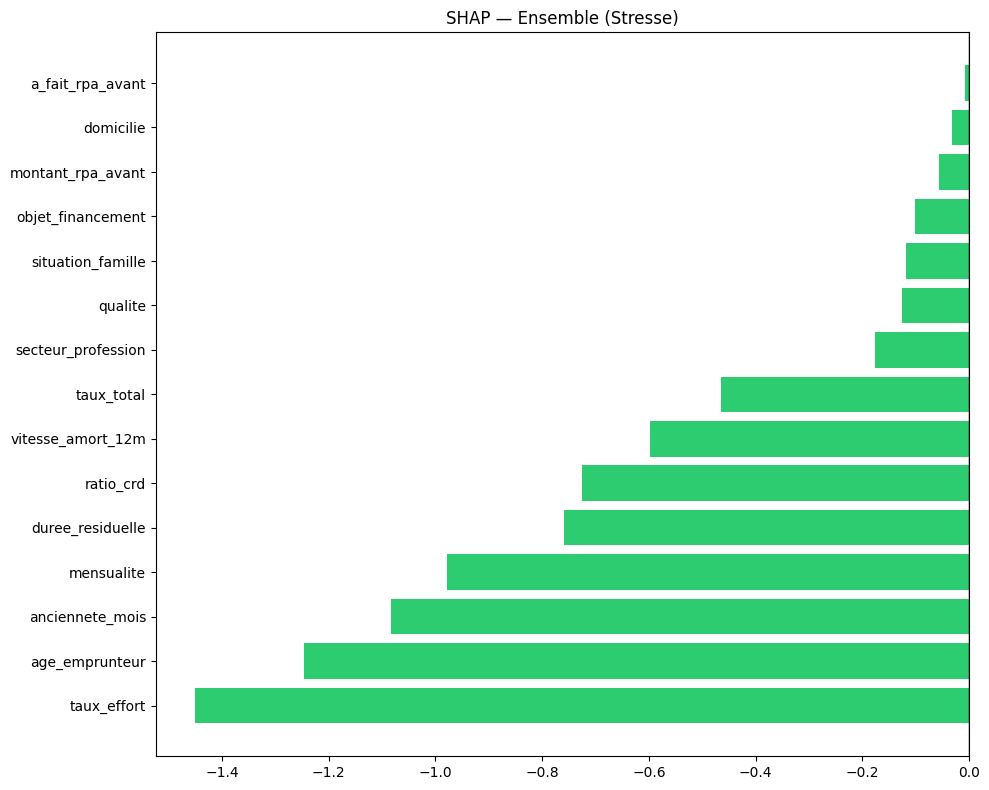


  ✔ Figure SHAP sauvegardée

  PARTIE 2 — LIME : Ensemble (Stresse)
  LIME sur : RandomForest (Stresse)

  Créance la plus risquée : #524 | PD=100.0000%

  Top 10 features LIME (créance #524, PD=100.0000%):
  a_fait_rpa_avant <= 0.00                           -0.0167  ↓ RPA
  age_emprunteur <= 36.50                            +0.0162  ↑ RPA
  anciennete_mois <= 28.80                           +0.0139  ↑ RPA
  taux_effort > 0.43                                 +0.0124  ↑ RPA
  duree_residuelle > 255.70                          +0.0092  ↑ RPA
  taux_total <= 4.80                                 +0.0080  ↑ RPA
  2.00 < secteur_profession <= 3.00                  +0.0058  ↑ RPA
  montant_rpa_avant <= 0.00                          -0.0039  ↓ RPA
  vitesse_amort_12m <= 0.02                          +0.0029  ↑ RPA
  objet_financement <= 0.00                          +0.0018  ↑ RPA


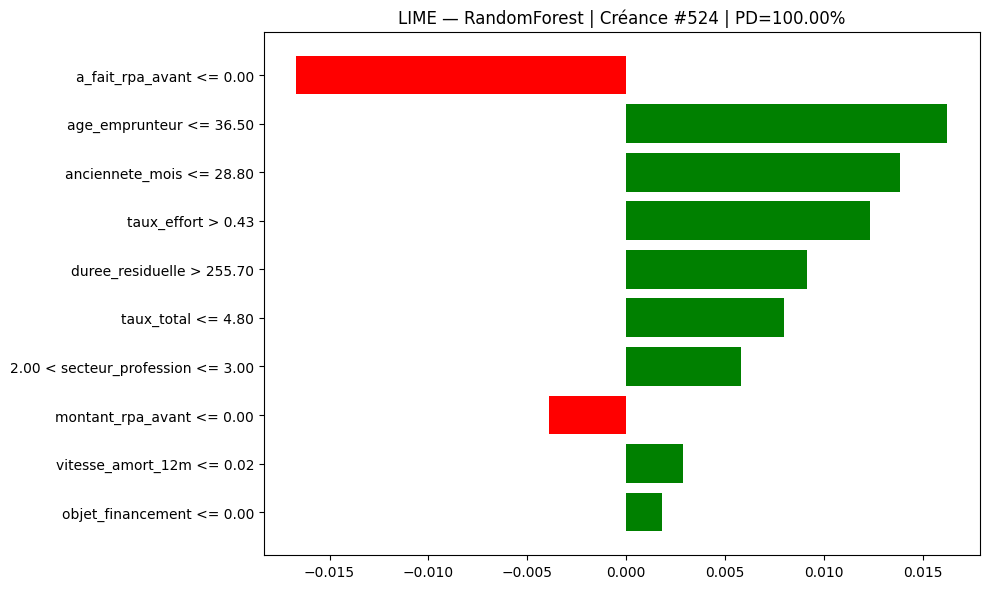


  ✔ Figure LIME sauvegardée

  ✔ BLOC 21 V3 TERMINÉ


In [ ]:
# ##############################################################################
# BLOC 21 V3 — EXPLICABILITÉ DU MEILLEUR MODÈLE (CORRIGÉ)
# ##############################################################################

import shap
import lime
import lime.lime_tabular

print("=" * 70)
print("  BLOC 21 V3 — EXPLICABILITÉ DU MEILLEUR MODÈLE")
print("=" * 70)

# ── 1. VÉRIFICATION DES VARIABLES DU BLOC 18 ───────────────────────────────
variables_bloc18 = ["MEILLEUR_MODELE", "MEILLEUR_SCENARIO", "RESULTATS"]
manquantes = [v for v in variables_bloc18 if v not in dir()]
if manquantes:
    print(f"  ❌ Variables manquantes du BLOC 18 : {manquantes}")
    print("  Ré-exécute le BLOC 18 avant.")
    raise RuntimeError("Variables du BLOC 18 manquantes.")

print(f"  ✔ Variables du BLOC 18 trouvées")
print(f"  Meilleur modèle   : {MEILLEUR_MODELE}")
print(f"  Meilleur scénario : {MEILLEUR_SCENARIO}")
print(f"  AUC test          : {RESULTATS[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]['auc']:.4f}")
print(f"  Rappel            : {RESULTATS[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]['Rappel']:.4f}")
print(f"  Seuil             : {RESULTATS[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]['Seuil']:.4f}")

# ── 2. PRÉPARATION DES DONNÉES ─────────────────────────────────────────────
# Vérifier que les données de test existent
if "df_test_raw" not in dir() or "df_train_raw" not in dir():
    raise RuntimeError("df_test_raw ou df_train_raw manquant. Ré-exécute les BLOCs 8-9.")

# Recréer X_test_tree (format arbre) pour SHAP
def preparer_tree_local(df_part):
    dc = df_part.copy()
    for c in FEATURES_NUM:
        dc[c] = dc[c].fillna(medians_train.get(c, dc[c].median()))
    for c in FEATURES_CAT:
        mv = modes_train.get(c, dc[c].mode()[0] if not dc[c].mode().empty else "INC")
        dc[c] = dc[c].fillna(mv)
        # Utiliser les catégories figées du train
        if c in CATEGORIES_FIXES:
            dc[c] = pd.Categorical(dc[c], categories=CATEGORIES_FIXES[c]).codes
        else:
            dc[c] = dc[c].astype("category").cat.codes
    return dc[FEATURES_NUM + FEATURES_CAT].values

X_test_tree = preparer_tree_local(df_test_raw)
X_train_tree = preparer_tree_local(df_train_raw)

# Features names pour les arbres
feat_names_tree = FEATURES_NUM + FEATURES_CAT

# Mapping catégoriel pour l'interprétation
cat_mappings = {}
for c in FEATURES_CAT:
    if c in CATEGORIES_FIXES:
        cat_mappings[c] = {i: cat for i, cat in enumerate(CATEGORIES_FIXES[c])}
        print(f"  ✔ Mapping {c}: {cat_mappings[c]}")

# ── 3. FONCTION SHAP POUR LE MODÈLE CHAMPION ─────────────────────────────

def calculer_shap_modele(modele_nom, scenario, X_local, n_expl, pour_train=False):
    """
    Calcule les valeurs SHAP pour un modèle individuel (pas l'ensemble).
    """
    if modele_nom == "Ensemble":
        # Pour l'ensemble, on prend le modèle le plus pondéré
        # Récupérer les poids depuis RESULTATS
        r_ens = RESULTATS.get(("Ensemble", scenario), {})

        # ★ CORRECTION : gérer le format des poids (liste ou dict)
        poids_raw = r_ens.get("poids", [0.33, 0.33, 0.34])

        # Convertir en dictionnaire si c'est une liste
        if isinstance(poids_raw, list):
            modeles_base = ["RegLog", "RandomForest", "XGBoost"]
            poids_dict = {m: poids_raw[i] if i < len(poids_raw) else 0
                         for i, m in enumerate(modeles_base)}
        elif isinstance(poids_raw, dict):
            poids_dict = poids_raw
        else:
            poids_dict = {"RegLog": 0.33, "RandomForest": 0.33, "XGBoost": 0.34}

        # Choisir le modèle avec le plus grand poids
        meilleur_base = max(poids_dict.items(), key=lambda x: x[1])[0]
        print(f"  Ensemble — modèle le plus pondéré : {meilleur_base} (poids={poids_dict[meilleur_base]:.3f})")

        # Appel récursif sur le modèle de base
        return calculer_shap_modele(meilleur_base, scenario, X_local, n_expl, pour_train)

    # --- Modèles individuels ---
    cle = (modele_nom, scenario)
    if cle not in MODELES_ENTRAINES:
        print(f"  ⚠ Modèle {modele_nom}-{scenario} non trouvé dans MODELES_ENTRAINES")
        return None, None, None

    modele = MODELES_ENTRAINES[cle]

    if modele_nom in ["RandomForest", "XGBoost"]:
        try:
            explainer = shap.TreeExplainer(modele)
            shap_values = explainer.shap_values(X_local[:n_expl])

            # Gérer le format de sortie de TreeExplainer
            if isinstance(shap_values, list):
                shap_values = shap_values[1]  # Classe positive
            elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
                shap_values = shap_values[:, :, 1]

            shap_values = np.asarray(shap_values)
            if shap_values.ndim != 2:
                shap_values = shap_values.reshape(shap_values.shape[0], -1)

            print(f"  ✔ TreeExplainer {modele_nom} | shape={shap_values.shape}")
            return shap_values, feat_names_tree, modele

        except Exception as e:
            print(f"  ⚠ TreeExplainer {modele_nom} échoué : {e}")
            return None, None, None

    elif modele_nom == "RegLog":
        # RegLog nécessite le format OHE + standardisé
        try:
            def reglog_predict_tree(X_batch):
                df_X = pd.DataFrame(X_batch, columns=feat_names_tree)
                # Reconvertir les codes catégoriels en valeurs
                for c in FEATURES_CAT:
                    if c in CATEGORIES_FIXES:
                        codes = df_X[c].round().astype(int).clip(0, len(CATEGORIES_FIXES[c])-1)
                        df_X[c] = [CATEGORIES_FIXES[c][k] for k in codes]

                # OHE + StandardScaler
                num = pd.DataFrame(scaler.transform(df_X[FEATURES_NUM]), columns=FEATURES_NUM)
                if FEATURES_CAT:
                    oh = pd.DataFrame(ohe.transform(df_X[FEATURES_CAT]),
                                     columns=ohe.get_feature_names_out(FEATURES_CAT))
                    X_lr = pd.concat([num, oh], axis=1).values
                else:
                    X_lr = num.values
                return modele.predict_proba(X_lr)[:, 1]

            # Background pour KernelExplainer
            bg = shap.sample(X_train_tree, min(100, len(X_train_tree)), random_state=42)
            explainer = shap.KernelExplainer(reglog_predict_tree, bg)
            shap_values = explainer.shap_values(X_local[:n_expl], nsamples=50)

            if isinstance(shap_values, list):
                shap_values = np.asarray(shap_values[1])
            else:
                shap_values = np.asarray(shap_values)

            if shap_values.ndim != 2:
                shap_values = shap_values.reshape(shap_values.shape[0], -1)

            print(f"  ✔ KernelExplainer RegLog | shape={shap_values.shape}")
            return shap_values, feat_names_tree, modele

        except Exception as e:
            print(f"  ⚠ KernelExplainer RegLog échoué : {e}")
            return None, None, None

    else:
        print(f"  ⚠ Modèle {modele_nom} non supporté pour SHAP")
        return None, None, None

# ── 4. CALCUL SHAP ─────────────────────────────────────────────────────────

N_BACKGROUND = 100
N_EXPLIQUER_TEST = 50

print("\n" + "=" * 70)
print(f"  PARTIE 1 — SHAP : {MEILLEUR_MODELE} ({MEILLEUR_SCENARIO})")
print("=" * 70)

# SHAP sur test (visualisation)
shap_test, feat_names_final, modele_obj = calculer_shap_modele(
    MEILLEUR_MODELE, MEILLEUR_SCENARIO, X_test_tree, N_EXPLIQUER_TEST, pour_train=False)

if shap_test is not None and feat_names_final is not None:
    # Moyenne des valeurs SHAP absolues
    mean_shap = np.abs(shap_test).mean(axis=0)

    df_shap = pd.DataFrame({
        "Variable": feat_names_final,
        "SHAP_moyen": shap_test.mean(axis=0),
        "SHAP_abs": mean_shap
    }).sort_values("SHAP_abs", ascending=False)

    print(f"\n  Top 15 variables SHAP :")
    print(f"  {'Variable':<35} {'SHAP moyen':>12} {'|SHAP|':>10}  Sens")
    print(f"  {'─'*70}")
    for _, row in df_shap.head(15).iterrows():
        sens = "↑ RISQUE" if row["SHAP_moyen"] > 0 else "↓ RISQUE"
        print(f"  {row['Variable']:<35} {row['SHAP_moyen']:>+12.4f} {row['SHAP_abs']:>10.4f}  {sens}")

    # Graphique
    fig, ax = plt.subplots(figsize=(10, 8))
    top15 = df_shap.head(15).sort_values("SHAP_moyen")
    colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in top15["SHAP_moyen"]]
    ax.barh(top15["Variable"], top15["SHAP_moyen"], color=colors)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"SHAP — {MEILLEUR_MODELE} ({MEILLEUR_SCENARIO})")
    plt.tight_layout()
    plt.savefig(chemin_sortie(f"RPA_SHAP_{MEILLEUR_MODELE}_{MEILLEUR_SCENARIO}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  ✔ Figure SHAP sauvegardée")

    # Sauvegarde CSV
    df_shap.to_csv(chemin_sortie(f"RPA_SHAP_{MEILLEUR_MODELE}_{MEILLEUR_SCENARIO}.csv"),
                   index=False, sep=";", decimal=",")
else:
    print("  ⚠ SHAP non disponible — passe à LIME.")

# ── 5. LIME (explication locale) ─────────────────────────────────────────

print("\n" + "=" * 70)
print(f"  PARTIE 2 — LIME : {MEILLEUR_MODELE} ({MEILLEUR_SCENARIO})")
print("=" * 70)

# Pour LIME, utiliser le modèle de base (pas l'ensemble)
modele_lime = MEILLEUR_MODELE if MEILLEUR_MODELE != "Ensemble" else "RandomForest"
scenario_lime = MEILLEUR_SCENARIO

if modele_lime == "Ensemble" or (modele_lime, scenario_lime) not in MODELES_ENTRAINES:
    # Fallback sur un modèle disponible
    for m in ["RandomForest", "XGBoost", "RegLog"]:
        if (m, scenario_lime) in MODELES_ENTRAINES:
            modele_lime = m
            break

print(f"  LIME sur : {modele_lime} ({scenario_lime})")

modele_obj = MODELES_ENTRAINES[(modele_lime, scenario_lime)]

# Préparer les données pour LIME
X_test_lime = X_test_tree
y_test_lime = RESULTATS[(MEILLEUR_MODELE, MEILLEUR_SCENARIO)]["p_test"]  # Probas du champion

# Créance la plus risquée
idx_risk = int(np.argmax(y_test_lime))
pd_risk = y_test_lime[idx_risk]
print(f"\n  Créance la plus risquée : #{idx_risk} | PD={pd_risk:.4%}")

# LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_tree,
    feature_names=feat_names_tree,
    class_names=["Sain", "RPA"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Fonction de prédiction pour LIME
def predict_fn_lime(X_batch):
    return modele_obj.predict_proba(X_batch)

# Explication
exp = explainer_lime.explain_instance(
    data_row=X_test_lime[idx_risk],
    predict_fn=predict_fn_lime,
    num_features=10,
    num_samples=2000
)

# Affichage
print(f"\n  Top 10 features LIME (créance #{idx_risk}, PD={pd_risk:.4%}):")
for feat, contrib in exp.as_list():
    sens = "↑ RPA" if contrib > 0 else "↓ RPA"
    print(f"  {feat:<45} {contrib:>+12.4f}  {sens}")

# Graphique
fig = exp.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title(f"LIME — {modele_lime} | Créance #{idx_risk} | PD={pd_risk:.2%}")
plt.tight_layout()
plt.savefig(chemin_sortie(f"RPA_LIME_{modele_lime}_{scenario_lime}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"\n  ✔ Figure LIME sauvegardée")

print("\n" + "=" * 70)
print("  ✔ BLOC 21 V3 TERMINÉ")
print("=" * 70)

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)

df_shap_display = df_shap.head(15).copy()
df_shap_display["Sens"] = df_shap_display["SHAP_moyen"].apply(lambda x: "↑ RISQUE" if x > 0 else "↓ RISQUE")
print(f"\n  Top 15 variables SHAP :")
display(df_shap_display[["Variable", "SHAP_moyen", "SHAP_abs", "Sens"]])

NameError: name 'df_shap' is not defined


  --- 22C. Top facteurs de risque du MODÈLE CHAMPION ---
  Modèle champion : Ensemble
  Scénario        : Stresse

  → Le champion est un Ensemble. Sélection du modèle de base le plus pondéré.
  → Modèle de base sélectionné : RandomForest (poids=7.004)
  ✔ Modèle RandomForest-Stresse chargé depuis la mémoire

  --- Extraction des facteurs de risque : RandomForest ---

  Top 15 facteurs de risque — RandomForest (Stresse) :
  Facteur                                             Valeur            Direction
  ────────────────────────────────────────────────────────────────────────────────
  secteur_profession [ENSEIGNEMENT]                  -0.0020   ↓ réduit le risque
  secteur_profession [SECURITE_DEFENSE]              +0.0018 ↑ augmente le risque
  anciennete_mois                                    +0.0010 ↑ augmente le risque
  secteur_profession [AUTRE]                         -0.0010   ↓ réduit le risque
  secteur_profession [ADMINISTRATION]                +0.0008 ↑ augmente le risqu

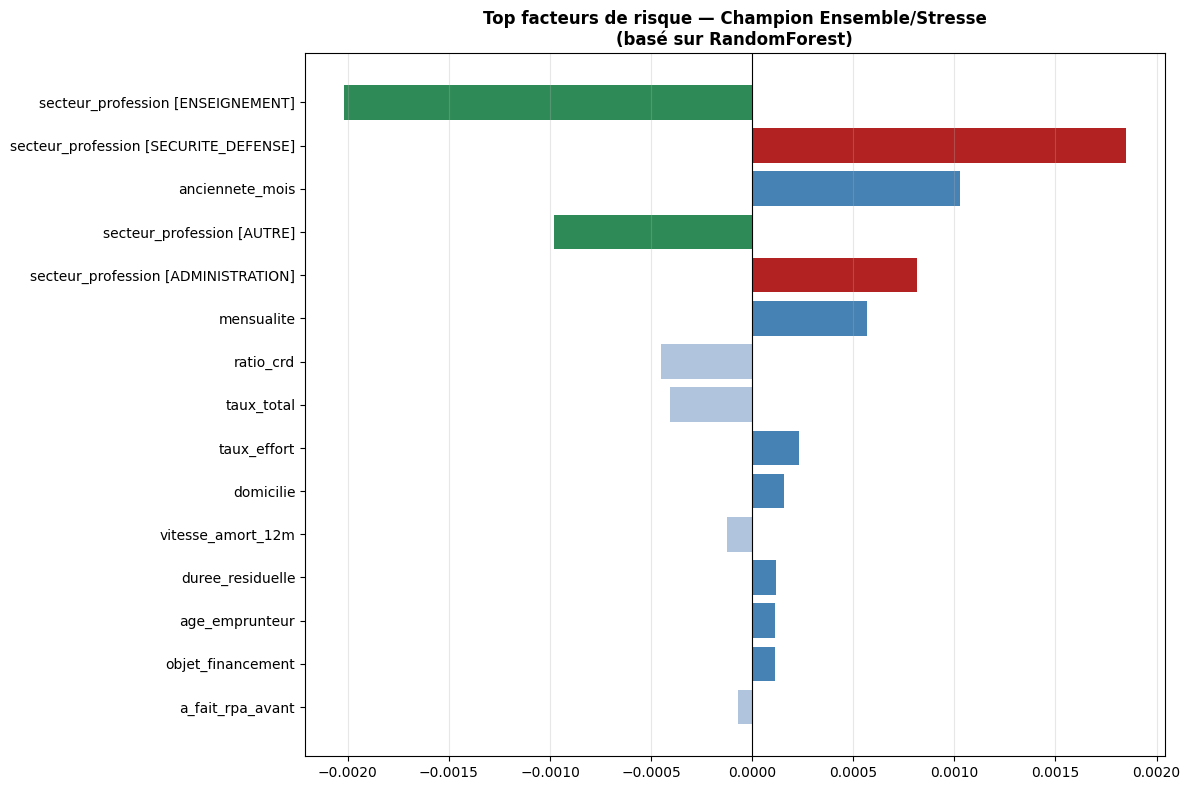


  ✔ RPA_facteurs_risque_CHAMPION.csv sauvegardé
  BLOC 22C terminé


In [ ]:
# ##############################################################################
# BLOC 22C — TOP FACTEURS DE RISQUE DU MODÈLE CHAMPION (Ensemble-Stressé)
# VERSION CORRIGÉE — focalisée sur le modèle champion
# ##############################################################################

separateur("22C. Top facteurs de risque du MODÈLE CHAMPION", 2)

# ── 1. VÉRIFICATION DU CHAMPION ─────────────────────────────────────────────
if "MEILLEUR_MODELE" not in dir() or "MEILLEUR_SCENARIO" not in dir():
    raise RuntimeError("MEILLEUR_MODELE et MEILLEUR_SCENARIO non définis. Exécute le BLOC 18 d'abord.")

print(f"  Modèle champion : {MEILLEUR_MODELE}")
print(f"  Scénario        : {MEILLEUR_SCENARIO}")

# ── 2. RECONSTRUCTION DES VARIABLES MANQUANTES ─────────────────────────────

# CATEGORIES_SECTEUR
if "CATEGORIES_SECTEUR" not in dir():
    if "CATEGORIES_FIXES" in dir() and "secteur_profession" in CATEGORIES_FIXES:
        CATEGORIES_SECTEUR = CATEGORIES_FIXES["secteur_profession"]
    elif "FEATURE_COLS" in dir():
        secteur_cols = [c for c in FEATURE_COLS if c.startswith("secteur_profession_")]
        CATEGORIES_SECTEUR = [c.replace("secteur_profession_", "") for c in secteur_cols]
    else:
        CATEGORIES_SECTEUR = ["ADMINISTRATION", "AUTRE", "ENSEIGNEMENT", "SECURITE_DEFENSE"]
    print(f"  ✔ CATEGORIES_SECTEUR : {CATEGORIES_SECTEUR}")

# Vérifier les variables essentielles
for v in ["FEATURE_COLS", "FEATURES_NUM", "FEATURES_CAT"]:
    if v not in dir():
        raise RuntimeError(f"{v} manquant. Ré-exécute les blocs précédents.")

# ── 3. CHARGER LE MODÈLE CHAMPION ───────────────────────────────────────────
modele_champion = None
modele_nom = MEILLEUR_MODELE
scenario = MEILLEUR_SCENARIO

# Si c'est un Ensemble, on prend le modèle de base le plus pondéré
if modele_nom == "Ensemble":
    print("\n  → Le champion est un Ensemble. Sélection du modèle de base le plus pondéré.")

    # Récupérer les poids depuis RESULTATS
    r_ens = RESULTATS.get(("Ensemble", scenario), {})
    poids_raw = r_ens.get("poids_meta", [0.33, 0.33, 0.34])

    # Convertir en dictionnaire si liste
    if isinstance(poids_raw, list):
        modeles_base = ["RegLog", "RandomForest", "XGBoost", "LSTM"]
        poids_dict = {m: poids_raw[i] if i < len(poids_raw) else 0
                     for i, m in enumerate(modeles_base)}
    else:
        poids_dict = poids_raw

    # Choisir le modèle avec le plus grand poids
    modele_nom = max(poids_dict.items(), key=lambda x: x[1])[0]
    print(f"  → Modèle de base sélectionné : {modele_nom} (poids={poids_dict[modele_nom]:.3f})")

# Charger le modèle
cle_modele = (modele_nom, scenario)
if cle_modele in MODELES_ENTRAINES:
    modele_champion = MODELES_ENTRAINES[cle_modele]
    print(f"  ✔ Modèle {modele_nom}-{scenario} chargé depuis la mémoire")
else:
    # Tentative de chargement depuis fichier
    import os
    dossier = os.path.join(DOSSIER_SORTIE, "modeles_rpa") if "DOSSIER_SORTIE" in dir() else "./modeles_rpa"
    chemin = os.path.join(dossier, f"{modele_nom.lower()}_{scenario}.pkl")
    if os.path.exists(chemin):
        modele_champion = joblib.load(chemin)
        print(f"  ✔ Modèle chargé depuis {chemin}")
    else:
        raise RuntimeError(f"Modèle {modele_nom}-{scenario} introuvable.")

# ── 4. EXTRAIRE LES FACTEURS DE RISQUE ─────────────────────────────────────
print(f"\n  --- Extraction des facteurs de risque : {modele_nom} ---")

if modele_nom == "RegLog":
    # Coefficients
    coefs = dict(zip(FEATURE_COLS, modele_champion.coef_[0]))
    noms_non_sect = [c for c in FEATURE_COLS if not c.startswith("secteur_profession_")]
    vals_non_sect = [coefs[c] for c in noms_non_sect]
    secteur_vals = {cat: coefs.get(f"secteur_profession_{cat}", 0.0) for cat in CATEGORIES_SECTEUR}

    # Créer le tableau
    lignes = []
    for nom, val in zip(noms_non_sect, vals_non_sect):
        lignes.append({"Facteur": nom, "Valeur": float(val), "EstSecteur": False, "Categorie": None})
    for cat, val in secteur_vals.items():
        lignes.append({"Facteur": f"secteur_profession [{cat}]", "Valeur": float(val),
                      "EstSecteur": True, "Categorie": cat})

    df_risque = pd.DataFrame(lignes)

elif modele_nom in ["RandomForest", "XGBoost"]:
    # SHAP
    features_tree = FEATURES_NUM + FEATURES_CAT
    noms_non_sect = [f for f in features_tree if f != "secteur_profession"]

    # Calculer SHAP
    explainer = shap.TreeExplainer(modele_champion)

    # Préparer X_test au format arbre
    X_test_tree = preparer_tree(df_test_raw) if "df_test_raw" in dir() else None
    if X_test_tree is None:
        raise RuntimeError("df_test_raw manquant pour calculer SHAP.")

    shap_values = explainer.shap_values(X_test_tree[:100])  # Échantillon pour rapidité

    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    # Moyenne des SHAP
    idx_non_sect = [features_tree.index(f) for f in noms_non_sect]
    vals_non_sect = shap_values[:, idx_non_sect].mean(axis=0)

    idx_secteur = features_tree.index("secteur_profession")
    secteur_vals = {}
    for i, cat in enumerate(CATEGORIES_SECTEUR):
        # Pour chaque catégorie, calculer le SHAP moyen quand elle est active
        mask = X_test_tree[:100, idx_secteur] == i
        if mask.sum() > 0:
            secteur_vals[cat] = shap_values[mask, idx_secteur].mean()
        else:
            secteur_vals[cat] = 0.0

    # Créer le tableau
    lignes = []
    for nom, val in zip(noms_non_sect, vals_non_sect):
        lignes.append({"Facteur": nom, "Valeur": float(val), "EstSecteur": False, "Categorie": None})
    for cat, val in secteur_vals.items():
        lignes.append({"Facteur": f"secteur_profession [{cat}]", "Valeur": float(val),
                      "EstSecteur": True, "Categorie": cat})

    df_risque = pd.DataFrame(lignes)

else:
    raise RuntimeError(f"Modèle {modele_nom} non supporté pour l'extraction des facteurs.")

# ── 5. TRIER ET AFFICHER ───────────────────────────────────────────────────
df_risque["AbsValeur"] = df_risque["Valeur"].abs()
df_risque = df_risque.sort_values("AbsValeur", ascending=False).head(15)
df_risque["Direction"] = np.where(df_risque["Valeur"] > 0, "↑ augmente le risque", "↓ réduit le risque")
df_risque = df_risque.drop(columns="AbsValeur").reset_index(drop=True)

print(f"\n  Top 15 facteurs de risque — {modele_nom} ({scenario}) :")
print(f"  {'Facteur':<45} {'Valeur':>12} {'Direction':>20}")
print(f"  {'─'*80}")
for _, row in df_risque.iterrows():
    print(f"  {row['Facteur']:<45} {row['Valeur']:>+12.4f} {row['Direction']:>20}")

# Secteurs dans le top
secteurs_top = df_risque[df_risque["EstSecteur"]]
if len(secteurs_top) > 0:
    plus_risque = secteurs_top.loc[secteurs_top["Valeur"].idxmax()]
    print(f"\n  ★ Secteur le plus à risque : {plus_risque['Categorie']} ({plus_risque['Valeur']:+.4f})")

# ── 6. GRAPHIQUE ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
df_plot = df_risque.iloc[::-1]  # Inverser pour barh

couleurs = []
for e, v in zip(df_plot["EstSecteur"], df_plot["Valeur"]):
    if e:
        couleurs.append("firebrick" if v > 0 else "seagreen")
    else:
        couleurs.append("steelblue" if v > 0 else "lightsteelblue")

ax.barh(df_plot["Facteur"], df_plot["Valeur"], color=couleurs)
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Top facteurs de risque — Champion {MEILLEUR_MODELE}/{MEILLEUR_SCENARIO}\n"
             f"(basé sur {modele_nom})", fontweight="bold")
ax.grid(alpha=.3, axis="x")

plt.tight_layout()
plt.savefig(chemin_sortie("RPA_facteurs_risque_CHAMPION.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 7. SAUVEGARDE ─────────────────────────────────────────────────────────
df_risque.to_csv(chemin_sortie("RPA_facteurs_risque_CHAMPION.csv"), index=False, sep=";", decimal=",")
print(f"\n  ✔ RPA_facteurs_risque_CHAMPION.csv sauvegardé")
print("  BLOC 22C terminé")

In [ ]:
# ##############################################################################
# BLOC 23 — INTERFACE DE SCORING RPA (Upload CSV + Saisie manuelle)
# ------------------------------------------------------------------------------
# Ce bloc permet de scorer de nouvelles créances avec le modèle champion retenu
# en BLOC 18 (MEILLEUR_MODELE × MEILLEUR_SCENARIO).
#
#   MODE 1 : Upload CSV         → scoring batch + CPR portefeuille (pondérée CRD)
#   MODE 2 : Saisie manuelle    → scoring individuel d'une créance
#
# Résultats :
#   - P(RPA) individuelle sur horizon 12 mois (Bâle II)
#   - Classification RPA / Pas de RPA selon le seuil optimal du champion
#   - CPR portefeuille agrégée (moyenne simple ET moyenne pondérée par CRD)
#   - Comparaison à la CPR vintage (référence ALM = 2,44 %)
#
# Confidentialité : utilise « le compartiment étudié » et « le cédant ».
# ##############################################################################

from google.colab import files
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import io

separateur("23. INTERFACE DE SCORING RPA")

# ##############################################################################
# 23.0 — RÉSOLUTION DU MODÈLE DE SCORING
# ------------------------------------------------------------------------------
# Si MEILLEUR_MODELE == "LSTM", le scoring requiert des séquences mensuelles
# (FENETRE_SEQ = 24 mois). Pour CSV/saisie manuelle sans historique panel, on
# bascule sur le meilleur modèle classique du MÊME scénario, avec avertissement
# explicite (cohérent avec votre logique de fallback PD).
#
# Si MEILLEUR_MODELE == "Ensemble", il a besoin des 4 modèles de base (dont
# LSTM séquentiel). En mode upload/saisie manuelle sans historique panel,
# le LSTM interne est approximé par la moyenne des 3 classiques.
# ##############################################################################

MODELES_CLASSIQUES = ["RegLog", "RandomForest", "XGBoost"]

if MEILLEUR_MODELE == "LSTM":
    candidats = (df_synthese_finale[
        (df_synthese_finale["Modele"].isin(MODELES_CLASSIQUES)) &
        (df_synthese_finale["Scenario"] == MEILLEUR_SCENARIO)]
        .sort_values("AUC_validation", ascending=False))
    SCORING_MODELE   = candidats.iloc[0]["Modele"]
    SCORING_SCENARIO = candidats.iloc[0]["Scenario"]
    LSTM_FALLBACK    = True
    print("  ⚠ Champion = LSTM : fallback sur le meilleur classique du même scénario.")
    print(f"  → Modèle de scoring : {SCORING_MODELE} × {SCORING_SCENARIO}")

elif MEILLEUR_MODELE == "Ensemble":
    SCORING_MODELE   = "Ensemble"
    SCORING_SCENARIO = MEILLEUR_SCENARIO
    LSTM_FALLBACK    = False
    print("  Champion = Ensemble : scoring via les 4 modèles de base.")
    print("  (Sans historique mensuel, le LSTM interne sera approximé par la moyenne des 3 classiques)")

else:
    SCORING_MODELE   = MEILLEUR_MODELE
    SCORING_SCENARIO = MEILLEUR_SCENARIO
    LSTM_FALLBACK    = False

SCORING_SEUIL = RESULTATS[(SCORING_MODELE, SCORING_SCENARIO)]["Seuil"]
SCORING_CPR   = RESULTATS[(SCORING_MODELE, SCORING_SCENARIO)]["cpr_pred"]

print("=" * 70)
print(f"""
  Modèle utilisé        : {SCORING_MODELE}
  Scénario              : {SCORING_SCENARIO}
  Seuil optimal         : {SCORING_SEUIL:.4f}
  CPR prédite (train)   : {SCORING_CPR:.4%}
  CPR vintage référence : {CPR_VINTAGE:.4%}
  CPR observée portefeuille : {CPR_OBSERVEE:.4%}
""")
print("=" * 70)


# ##############################################################################
# 23.1 — FONCTIONS DE PRÉPROCESSING (alignées sur BLOC 9 du pipeline)
# ##############################################################################

def preprocess_new_data_rpa(df_new):
    """
    Applique le même préprocessing que le pipeline d'entraînement :
    - Winsorisation P1-P99 (bornes apprises sur TRAIN, dans winsor_bounds)
    - Imputation médiane (medians_train) / mode (modes_train)
    - Conserve uniquement les colonnes FEATURES_NUM + FEATURES_CAT attendues
    """
    df = df_new.copy()

    # 1. Compléter les colonnes manquantes par médiane/mode du train
    for c in FEATURES_NUM:
        if c not in df.columns:
            df[c] = medians_train[c]
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(medians_train[c])

    for c in FEATURES_CAT:
        if c not in df.columns:
            df[c] = modes_train[c]
        df[c] = df[c].fillna(modes_train[c]).astype(str)

    # 2. Winsorisation (bornes train)
    for col, (p1, p99) in winsor_bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=p1, upper=p99)

    return df


def predict_proba_rpa(df_new):
    """
    Calcule P(RPA) avec le modèle de scoring retenu.
    """
    df_p = preprocess_new_data_rpa(df_new)
    modele = MODELES_ENTRAINES[(SCORING_MODELE, SCORING_SCENARIO)]

    if SCORING_MODELE == "RegLog":
        X_new = build_lr_matrix(df_p)
        y_proba = modele.predict_proba(X_new)[:, 1]
    elif SCORING_MODELE in ("RandomForest", "XGBoost"):
        X_new = preparer_tree(df_p)
        y_proba = modele.predict_proba(X_new)[:, 1]
    elif SCORING_MODELE == "Ensemble":
        # Calcul des 4 probabilités de base
        p_reglog = MODELES_ENTRAINES[("RegLog", SCORING_SCENARIO)].predict_proba(build_lr_matrix(df_p))[:, 1]
        p_rf = MODELES_ENTRAINES[("RandomForest", SCORING_SCENARIO)].predict_proba(preparer_tree(df_p))[:, 1]
        p_xgb = MODELES_ENTRAINES[("XGBoost", SCORING_SCENARIO)].predict_proba(preparer_tree(df_p))[:, 1]
        if "ie_affaire" in df_p.columns:
            ids_d = df_p["ie_affaire"].values
            X_seq_d = construire_sequences(df_avant, ids_d)
            X_seq_d = normaliser_seq(X_seq_d)
            X_static_d = build_lr_matrix(df_p)
            p_lstm = MODELES_ENTRAINES[("LSTM", SCORING_SCENARIO)].predict(
                {"seq_input": X_seq_d, "static_input": X_static_d}, verbose=0).ravel()
        else:
            # Fallback interne : moyenne des 3 classiques si pas d'historique LSTM
            p_lstm = (p_reglog + p_rf + p_xgb) / 3.0
        X_meta = np.column_stack([p_reglog, p_rf, p_xgb, p_lstm])
        y_proba = modele.predict_proba(X_meta)[:, 1]
    else:
        y_proba = None

    # Calibration isotonique post-hoc si elle a été apprise
    cle_calib = (SCORING_MODELE, SCORING_SCENARIO)
    if CALIBRER_PROBABILITES and cle_calib in CALIBRATEURS:
        y_proba = CALIBRATEURS[cle_calib].transform(y_proba)

    return y_proba


# ##############################################################################
# 23.2 — FONCTION D'AFFICHAGE DES RÉSULTATS (CSV + portefeuille)
# ##############################################################################

def afficher_resultats_rpa(df_input, y_proba, label_source=""):
    """
    Affiche :
      - Tableau de scoring (P(RPA) + classification + niveau de risque)
      - CPR portefeuille (moyenne simple ET pondérée par CRD si disponible)
      - Distribution des P(RPA) + camembert par niveau de risque
      - Comparaison à la CPR vintage
    """
    df_res = df_input.copy()

    # ── P(RPA) individuelle et classification ─────────────────────────────────
    df_res["P_RPA (%)"]      = (y_proba * 100).round(4)
    df_res["Classification"] = np.where(
        y_proba >= SCORING_SEUIL, "RPA ⚠", "Pas de RPA ✓")
    df_res["Niveau_risque"]  = pd.cut(
        y_proba,
        bins  =[-1e-9, 0.05, 0.15, 0.30, 1.0],
        labels=["Faible", "Modéré", "Élevé", "Très élevé"])

    # ── CPR portefeuille — moyenne simple et pondérée CRD ─────────────────────
    cpr_simple = float(y_proba.mean())

    crd_col = next((c for c in ["crd", "CRD", "capital_restant_du"]
                    if c in df_input.columns), None)
    if crd_col is not None:
        poids       = df_input[crd_col].fillna(0).clip(lower=0).values
        if poids.sum() > 0:
            cpr_ponderee = float((y_proba * poids).sum() / poids.sum())
        else:
            cpr_ponderee = np.nan
    else:
        cpr_ponderee = np.nan

    n_rpa_pred = int((y_proba >= SCORING_SEUIL).sum())
    n_total    = len(y_proba)

    # ── Bandeau récapitulatif ─────────────────────────────────────────────────
    print(f"\n  {'═'*68}")
    print(f"  RÉSULTATS DE SCORING RPA — {label_source}")
    print(f"  {'═'*68}")
    print(f"  Créances scorées             : {n_total:,}")
    print(f"  RPA prédits (seuil={SCORING_SEUIL:.4f}) : "
          f"{n_rpa_pred} ({n_rpa_pred/n_total:.2%})")
    print(f"  CPR portefeuille — moyenne simple   : {cpr_simple:.4%}")
    if not np.isnan(cpr_ponderee):
        print(f"  CPR portefeuille — pondérée CRD     : {cpr_ponderee:.4%}  "
              f"(lecture ALM)")
    else:
        print(f"  CPR portefeuille — pondérée CRD     : non calculée "
              f"(colonne CRD absente)")
    print(f"  CPR vintage (référence ALM)         : {CPR_VINTAGE:.4%}")
    ecart = (cpr_simple - CPR_VINTAGE) * 100
    print(f"  Écart vs vintage (moyenne simple)   : {ecart:+.4f} pts")
    print(f"  {'═'*68}")

    # ── Distribution par niveau de risque ─────────────────────────────────────
    print(f"\n  Distribution par niveau de risque RPA :")
    print(f"  {'─'*45}")
    for niveau in ["Faible", "Modéré", "Élevé", "Très élevé"]:
        n_niv = (df_res["Niveau_risque"] == niveau).sum()
        pct   = n_niv / n_total * 100
        print(f"  {niveau:<12} : {n_niv:>6,} créances ({pct:>6.2f}%)")
    print(f"  {'─'*45}")

    # ── Tableau (10 premières lignes) ─────────────────────────────────────────
    cols_aff = (["ie_affaire"] if "ie_affaire" in df_res.columns else []) + [
        "P_RPA (%)", "Classification", "Niveau_risque"]
    print(f"\n  Aperçu des 10 premières créances :")
    display(df_res[cols_aff].head(10).style
        .applymap(lambda v: "color: #c0392b; font-weight: bold"
                  if v == "RPA ⚠" else
                  ("color: #27ae60" if v == "Pas de RPA ✓" else ""),
                  subset=["Classification"])
        .format({"P_RPA (%)": "{:.4f}%"})
        .set_caption(f"Scoring RPA — {label_source}"))

    # ── Graphique distribution + camembert ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Distribution des P(RPA) — {label_source}\n"
        f"le compartiment étudié | Modèle : {SCORING_MODELE} × {SCORING_SCENARIO}",
        fontweight="bold", fontsize=11)

    axes[0].hist(y_proba, bins=50, color="#2980b9",
                 edgecolor="white", alpha=0.85)
    axes[0].axvline(SCORING_SEUIL, color="#c0392b", ls="--", lw=2,
                    label=f"Seuil = {SCORING_SEUIL:.4f}")
    axes[0].axvline(cpr_simple, color="#e67e22", ls="-.", lw=2,
                    label=f"CPR moy. = {cpr_simple:.4%}")
    axes[0].axvline(CPR_VINTAGE, color="black", ls=":", lw=1.5,
                    label=f"CPR vintage = {CPR_VINTAGE:.2%}")
    axes[0].set_xlabel("P(RPA) individuelle")
    axes[0].set_ylabel("Nombre de créances")
    axes[0].set_title("Distribution des P(RPA) individuelles")
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    niveaux  = ["Faible", "Modéré", "Élevé", "Très élevé"]
    counts   = [(df_res["Niveau_risque"] == n).sum() for n in niveaux]
    couleurs = ["#27ae60", "#f1c40f", "#e67e22", "#c0392b"]
    # Retirer niveaux à 0 pour éviter labels parasites
    niv_nz, cnt_nz, col_nz = zip(*[(n, c, col) for n, c, col
                                    in zip(niveaux, counts, couleurs) if c > 0])
    axes[1].pie(cnt_nz, labels=niv_nz, colors=col_nz,
                autopct="%1.1f%%", startangle=90,
                wedgeprops={"edgecolor": "white", "linewidth": 2})
    axes[1].set_title("Répartition par niveau de risque RPA")

    plt.tight_layout()
    nom_fig = f"RPA_Scoring_{label_source.replace(' ', '_')}.png"
    plt.savefig(chemin_sortie(nom_fig), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✔ {nom_fig} sauvegardé")

    return df_res


# ##############################################################################
# 23.3 — MODE 1 : UPLOAD CSV
# ##############################################################################

print("\n" + "=" * 70)
print("  MODE 1 — UPLOAD CSV")
print("=" * 70)
print("""
  Instructions :
   1. Préparez un fichier CSV avec les mêmes colonnes que baseclient.xlsx
      (au minimum : les variables présentes dans FEATURES_NUM + FEATURES_CAT).
   2. Si la colonne 'crd' est présente, la CPR portefeuille sera également
      calculée pondérée par CRD (lecture ALM).
   3. Exécutez la cellule pour uploader le fichier.
""")

def scorer_csv_rpa():
    print("  Veuillez uploader votre fichier CSV...")
    uploaded = files.upload()

    for nom_fichier, contenu in uploaded.items():
        print(f"\n  Fichier reçu : {nom_fichier}")

        # Lecture (auto-détection séparateur ; , ou \t, décimale , ou .)
        try:
            df_csv = pd.read_csv(io.BytesIO(contenu), sep=None,
                                 engine="python", decimal=",")
        except Exception:
            df_csv = pd.read_csv(io.BytesIO(contenu), sep=None,
                                 engine="python", decimal=".")
        print(f"  Shape : {df_csv.shape[0]:,} créances × {df_csv.shape[1]} colonnes")

        # Si on est en fallback LSTM, l'utilisateur doit savoir
        if LSTM_FALLBACK:
            print(f"\n  ⚠ Rappel : champion = LSTM, scoring fait avec {SCORING_MODELE}")
            print( "    (LSTM nécessite l'historique mensuel des créances).")
        elif SCORING_MODELE == "Ensemble":
            if "ie_affaire" not in df_csv.columns:
                print(f"\n  ⚠ Rappel : Ensemble actif mais colonne 'ie_affaire' absente.")
                print( "    Le LSTM interne sera approximé par la moyenne des 3 classiques.")

        # Scoring
        try:
            y_proba = predict_proba_rpa(df_csv)
            df_res  = afficher_resultats_rpa(df_csv, y_proba,
                                             label_source="Upload_CSV")

            # Sauvegarde résultats
            cols_export = ["P_RPA (%)", "Classification", "Niveau_risque"]
            if "ie_affaire" in df_res.columns:
                cols_export = ["ie_affaire"] + cols_export
            nom_sortie = chemin_sortie("RPA_Resultats_Scoring_CSV.csv")
            df_res[cols_export].to_csv(nom_sortie, index=False,
                                        sep=";", decimal=",")
            print(f"  ✔ Résultats détaillés sauvegardés : {nom_sortie}")

        except Exception as e:
            print(f"  ✗ Erreur lors du scoring : {e}")
            import traceback; traceback.print_exc()

# Décommentez la ligne suivante pour activer l'upload :
# scorer_csv_rpa()


# ##############################################################################
# 23.4 — MODE 2 : SAISIE MANUELLE
# ##############################################################################

print("\n" + "=" * 70)
print("  MODE 2 — SAISIE MANUELLE")
print("=" * 70)
print("""
  Saisissez les caractéristiques d'une créance individuelle.
  Les variables non renseignées seront imputées par la médiane (numériques)
  ou le mode (catégorielles) appris sur l'échantillon TRAIN.
""")

# ── Variables numériques à saisir (les plus pertinentes selon SHAP/importance)
VARS_NUM_MANUELLES = {
    "anciennete_mois"    : ("Ancienneté du crédit (mois)",            60.0),
    "duree_residuelle"   : ("Durée résiduelle (mois)",                120.0),
    "ratio_crd"          : ("Ratio CRD / Montant initial (0–1)",      0.70),
    "taux_effort"        : ("Taux d'effort (mensualité×12 / revenu)", 0.30),
    "age_emprunteur"     : ("Âge de l'emprunteur (années)",           45.0),
    "mensualite"         : ("Mensualité (MAD)",                       3000.0),
    "taux_total"         : ("Taux total du crédit (%)",               5.5),
    "duree"              : ("Durée initiale du crédit (mois)",        240.0),
    "nb_obs_avant"       : ("Nb. d'observations historiques",         24.0),
    "nb_imp_cumul"       : ("Nb. d'impayés cumulés",                  0.0),
    "mt_imp_cumul"       : ("Montant impayé cumulé (MAD)",            0.0),
    "a_eu_impaye"        : ("A eu un impayé (0=Non, 1=Oui)",          0.0),
    "mois_depuis_1er_imp": ("Mois depuis le 1er impayé (0 si aucun)", 0.0),
    "ratio_mois_sains"   : ("Ratio mois sains / total (0–1)",         0.95),
    "a_fait_rpa_avant"   : ("A déjà fait une RPA (0=Non, 1=Oui)",     0.0),
    "montant_rpa_avant"  : ("Montant RPA antérieur (MAD)",            0.0),
    "vitesse_amort_12m"  : ("Vitesse d'amortissement 12 mois (0–1)",  0.05),
}
VARS_NUM_MANUELLES = {k: v for k, v in VARS_NUM_MANUELLES.items()
                       if k in FEATURES_NUM}

# ── Variables catégorielles : dropdown avec les catégories du train
VARS_CAT_MANUELLES = {c: CATEGORIES_FIXES[c] for c in FEATURES_CAT
                      if c in CATEGORIES_FIXES}

# ── Création des widgets ──────────────────────────────────────────────────────
print("  Renseignez les variables ci-dessous :\n")
widgets_dict = {}

# Numériques
print("  ─── Variables numériques ───")
for var, (label, defaut) in VARS_NUM_MANUELLES.items():
    w = widgets.FloatText(
        value=float(defaut),
        description=f"{label} :",
        style={"description_width": "330px"},
        layout=widgets.Layout(width="560px"))
    widgets_dict[var] = w
    display(w)

# Catégorielles
print("\n  ─── Variables catégorielles ───")
for var, options in VARS_CAT_MANUELLES.items():
    w = widgets.Dropdown(
        options=options,
        value=modes_train.get(var, options[0]),
        description=f"{var} :",
        style={"description_width": "330px"},
        layout=widgets.Layout(width="560px"))
    widgets_dict[var] = w
    display(w)

# Bouton de scoring
btn_scorer = widgets.Button(
    description="▶ Calculer la probabilité de RPA",
    button_style="success",
    layout=widgets.Layout(width="260px", height="42px"))
output_manuel = widgets.Output()


def on_click_scorer_rpa(b):
    with output_manuel:
        clear_output()
        print("\n  Calcul en cours...")

        # Construire le DataFrame depuis les widgets
        valeurs = {var: [w.value] for var, w in widgets_dict.items()}
        df_manuel = pd.DataFrame(valeurs)

        # Scoring
        try:
            y_proba = predict_proba_rpa(df_manuel)
            p_rpa   = float(y_proba[0])
            classif = "RPA ⚠" if p_rpa >= SCORING_SEUIL else "Pas de RPA ✓"
            niveau  = ("Très élevé" if p_rpa >= 0.30 else
                       "Élevé"      if p_rpa >= 0.15 else
                       "Modéré"     if p_rpa >= 0.05 else "Faible")
            couleur = "#c0392b" if "RPA ⚠" in classif else "#27ae60"

            # Message spécifique si Ensemble avec fallback LSTM
            msg_ensemble = ""
            if SCORING_MODELE == "Ensemble" and "ie_affaire" not in df_manuel.columns:
                msg_ensemble = "<br><small>(LSTM interne approximé — saisie manuelle)</small>"

            display(HTML(f"""
            <div style="border:2px solid {couleur}; border-radius:10px;
                        padding:18px; margin:12px; max-width:560px;
                        font-family: 'Segoe UI', Arial, sans-serif;">
              <h3 style="color:{couleur}; margin:0 0 8px 0;">
                {classif}
              </h3>
              <hr style="border-color:{couleur}; opacity:0.4;">
              <table style="width:100%; font-size:14px; border-spacing:0 6px;">
                <tr>
                  <td><b>P(RPA) à 12 mois</b></td>
                  <td style="color:{couleur}; font-weight:bold; text-align:right;">
                    {p_rpa:.4%}
                  </td>
                </tr>
                <tr>
                  <td><b>Niveau de risque RPA</b></td>
                  <td style="text-align:right;">{niveau}</td>
                </tr>
                <tr>
                  <td><b>Seuil de décision</b></td>
                  <td style="text-align:right;">{SCORING_SEUIL:.4f}</td>
                </tr>
                <tr>
                  <td><b>Modèle utilisé</b></td>
                  <td style="text-align:right;">{SCORING_MODELE} × {SCORING_SCENARIO}</td>
                </tr>
                <tr>
                  <td colspan="2" style="text-align:center; color:#7f8c8d; font-size:12px;">
                    {msg_ensemble}
                  </td>
                </tr>
                <tr>
                  <td><b>CPR vintage référence</b></td>
                  <td style="text-align:right;">{CPR_VINTAGE:.4%}</td>
                </tr>
                <tr>
                  <td><b>CPR observée portefeuille</b></td>
                  <td style="text-align:right;">{CPR_OBSERVEE:.4%}</td>
                </tr>
              </table>
              <p style="font-size:12px; color:#7f8c8d; margin-top:10px;">
                Lecture : la P(RPA) est la probabilité que cette créance fasse
                l'objet d'un remboursement anticipé partiel ou total sur les
                12 prochains mois (horizon Bâle II). Pour la lecture ALM, c'est
                la CPR portefeuille (agrégée) qui est utilisée — non la P(RPA)
                individuelle.
              </p>
            </div>
            """))

        except Exception as e:
            print(f"  ✗ Erreur : {e}")
            import traceback; traceback.print_exc()


btn_scorer.on_click(on_click_scorer_rpa)
display(btn_scorer)
display(output_manuel)


# ##############################################################################
# 23.5 — RÉCAPITULATIF
# ##############################################################################

print("\n" + "=" * 70)
print("  BLOC 23 TERMINÉ — INTERFACE DE SCORING RPA OPÉRATIONNELLE ✔")
print("=" * 70)
fallback_msg = ""
if LSTM_FALLBACK:
    fallback_msg = f"  (fallback LSTM → {SCORING_MODELE})"
elif MEILLEUR_MODELE == "Ensemble" and SCORING_MODELE != "Ensemble":
    fallback_msg = "  (fallback Ensemble → classique, historique manquant)"
elif MEILLEUR_MODELE == "Ensemble":
    fallback_msg = "  (Ensemble actif — LSTM approximé si historique absent)"

print(f"""
  Champion BLOC 18      : {MEILLEUR_MODELE} × {MEILLEUR_SCENARIO}
  Modèle de scoring     : {SCORING_MODELE} × {SCORING_SCENARIO}
  {fallback_msg}
  Seuil optimal         : {SCORING_SEUIL:.4f}
  CPR vintage référence : {CPR_VINTAGE:.4%}

  Fichiers produits :
   ├── RPA_Scoring_Upload_CSV.png
   ├── RPA_Resultats_Scoring_CSV.csv
   └── Saisie manuelle : affichage inline (HTML)
""")


  23. INTERFACE DE SCORING RPA
  Champion = Ensemble : scoring via les 4 modèles de base.
  (Sans historique mensuel, le LSTM interne sera approximé par la moyenne des 3 classiques)

  Modèle utilisé        : Ensemble
  Scénario              : Stresse
  Seuil optimal         : 0.0160
  CPR prédite (train)   : 1.5253%
  CPR vintage référence : 2.4400%
  CPR observée portefeuille : 1.6461%


  MODE 1 — UPLOAD CSV

  Instructions :
   1. Préparez un fichier CSV avec les mêmes colonnes que baseclient.xlsx
      (au minimum : les variables présentes dans FEATURES_NUM + FEATURES_CAT).
   2. Si la colonne 'crd' est présente, la CPR portefeuille sera également
      calculée pondérée par CRD (lecture ALM).
   3. Exécutez la cellule pour uploader le fichier.


  MODE 2 — SAISIE MANUELLE

  Saisissez les caractéristiques d'une créance individuelle.
  Les variables non renseignées seront imputées par la médiane (numériques)
  ou le mode (catégorielles) appris sur l'échantillon TRAIN.

  Renseign

FloatText(value=60.0, description='Ancienneté du crédit (mois) :', layout=Layout(width='560px'), style=Descrip…

FloatText(value=120.0, description='Durée résiduelle (mois) :', layout=Layout(width='560px'), style=Descriptio…

FloatText(value=0.7, description='Ratio CRD / Montant initial (0–1) :', layout=Layout(width='560px'), style=De…

FloatText(value=0.3, description="Taux d'effort (mensualité×12 / revenu) :", layout=Layout(width='560px'), sty…

...

Dropdown(description='secteur_profession :', index=3, layout=Layout(width='560px'), options=('ADMINISTRATION',…

Dropdown(description='situation_famille :', index=2, layout=Layout(width='560px'), options=('AUTRE', 'C', 'M')…

Button(button_style='success', description='▶ Calculer la probabilité de RPA', layout=Layout(height='42px', wi…

Output()


  BLOC 23 TERMINÉ — INTERFACE DE SCORING RPA OPÉRATIONNELLE ✔

  Champion BLOC 18      : Ensemble × Stresse
  Modèle de scoring     : Ensemble × Stresse
    (Ensemble actif — LSTM approximé si historique absent)
  Seuil optimal         : 0.0160
  CPR vintage référence : 2.4400%

  Fichiers produits :
   ├── RPA_Scoring_Upload_CSV.png
   ├── RPA_Resultats_Scoring_CSV.csv
   └── Saisie manuelle : affichage inline (HTML)

